## <h2 style="color: #9983b8;">Import Libraries</h2>

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score


# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# XGBoost evaluations
from xgboost import XGBClassifier 

# Save trained models
import joblib

# Plot styling
sns.set_style("whitegrid")
plt.style.use("seaborn-v0_8")

print("Libraries imported successfully.")

Libraries imported successfully.


## <h2 style="color: #cb236f;">Load feature-engineered dataset</h2>

In [2]:
df = pd.read_csv("/Users/laxmigupte/Desktop/Forest-fire-risk-project/data/processed/forestfires_modeling_ready.csv")
print("Modeling ready dataset loaded successfully.")

Modeling ready dataset loaded successfully.


## <h2 style="color: #cb236f;">Define Features and Target Variable</h2>

In [3]:
target = "fire_severity_binary"

# Separate features and target
X = df.drop(columns=[target])
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.value_counts())

Features shape: (513, 13)
Target shape: (513,)

Feature columns:
['x_coordinate', 'y_coordinate', 'fine_fuel_moisture_code', 'duff_moisture_code', 'drought_code', 'initial_spread_index', 'temp', 'relative_humidity', 'log_wind', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

Target classes:
fire_severity_binary
Low Severity     257
High Severity    256
Name: count, dtype: int64


In [4]:
# Check for target leakage or unwanted columns inside X

leakage_columns = [
    "fire_severity_binary",
    "wildfire_risk_binary",
    "area",
    "log_area"
]

overlap_columns = [
    "month",
    "day",
    "month_num",
    "day_num",
    "wind",
    "rain"
]

leakage_found = [col for col in leakage_columns if col in X.columns]
overlap_found = [col for col in overlap_columns if col in X.columns]

print("Leakage columns found in X:", leakage_found)
print("Overlapping / raw columns found in X:", overlap_found)

assert len(leakage_found) == 0, "Target leakage found in X!"
assert len(overlap_found) == 0, "Raw or overlapping columns found in X!"

Leakage columns found in X: []
Overlapping / raw columns found in X: []


## <h2 style="color: #cb236f;">Data Overview</h2>

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

display(df.head())

Dataset Shape: (513, 14)

Columns:
['x_coordinate', 'y_coordinate', 'fine_fuel_moisture_code', 'duff_moisture_code', 'drought_code', 'initial_spread_index', 'temp', 'relative_humidity', 'log_wind', 'fire_severity_binary', 'month_sin', 'month_cos', 'day_sin', 'day_cos']

Data types:
x_coordinate                 int64
y_coordinate                 int64
fine_fuel_moisture_code    float64
duff_moisture_code         float64
drought_code               float64
initial_spread_index       float64
temp                       float64
relative_humidity            int64
log_wind                   float64
fire_severity_binary        object
month_sin                  float64
month_cos                  float64
day_sin                    float64
day_cos                    float64
dtype: object


,x_coordinate,y_coordinate,fine_fuel_moisture_code,duff_moisture_code,drought_code,initial_spread_index,temp,relative_humidity,log_wind,fire_severity_binary,month_sin,month_cos,day_sin,day_cos
0,7,5,86.2,26.2,94.3,5.1,8.2,51,2.041220,Low Severity,1.000000,6.123234e-17,-9.749279e-01,-0.222521
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.641854,Low Severity,-0.866025,5.000000e-01,9.749279e-01,-0.222521
2,7,4,90.6,43.7,686.9,6.7,14.6,33,0.832909,Low Severity,-0.866025,5.000000e-01,-7.818315e-01,0.623490
3,8,6,91.7,33.3,77.5,9.0,8.3,97,1.609438,Low Severity,1.000000,6.123234e-17,-9.749279e-01,-0.222521
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.029619,Low Severity,1.000000,6.123234e-17,-2.449294e-16,1.000000


## <h2 style="color: #cb236f;">Target class distribution</h2>

In [6]:
print("Fire severity target distribution:")
print(y.value_counts())

print("\nFire severity target distribution (%):")
print(y.value_counts(normalize=True) * 100)

Fire severity target distribution:
fire_severity_binary
Low Severity     257
High Severity    256
Name: count, dtype: int64

Fire severity target distribution (%):
fire_severity_binary
Low Severity     50.097466
High Severity    49.902534
Name: proportion, dtype: float64


## <h2 style="color: #cb236f;">Visualise target class distribution</h2>

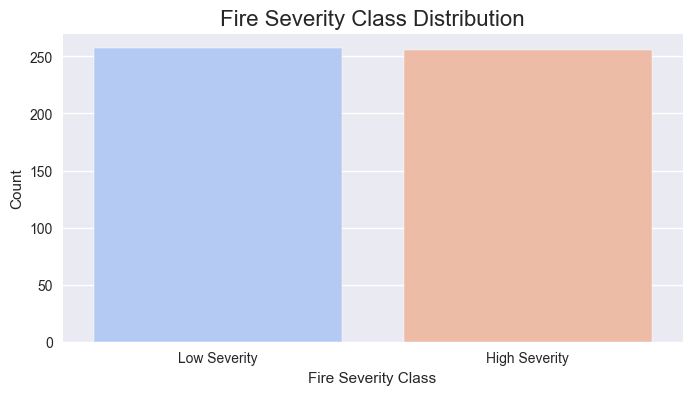

In [7]:
plt.figure(figsize=(8,4))

sns.countplot(
    x=y,
    hue=y,
    palette="coolwarm",
    order=["Low Severity", "High Severity"],
    legend=False
)

plt.title("Fire Severity Class Distribution", fontsize=16)
plt.xlabel("Fire Severity Class")
plt.ylabel("Count")

plt.show()

<div style="color:#60b9e5;">

## <h4>Insights:

</h4>
 </div>

## <h1 style="color: #9983b8;">TRAIN-TEST SPLIT</h1>

In [8]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (410, 13)
Testing Features Shape: (103, 13)
Training Target Shape: (410,)
Testing Target Shape: (103,)


## <h4 style="color: #6b9c80;">- Training set class distribution</h4>

In [9]:
print(y_train.value_counts(normalize=True))

fire_severity_binary
High Severity    0.5
Low Severity     0.5
Name: proportion, dtype: float64


## <h4 style="color: #6b9c80;">- Testing set class distribution</h4>

In [10]:
print(y_test.value_counts(normalize=True))

fire_severity_binary
Low Severity     0.504854
High Severity    0.495146
Name: proportion, dtype: float64


## <h2 style="color: #cb236f;">Training set distribution</h2>

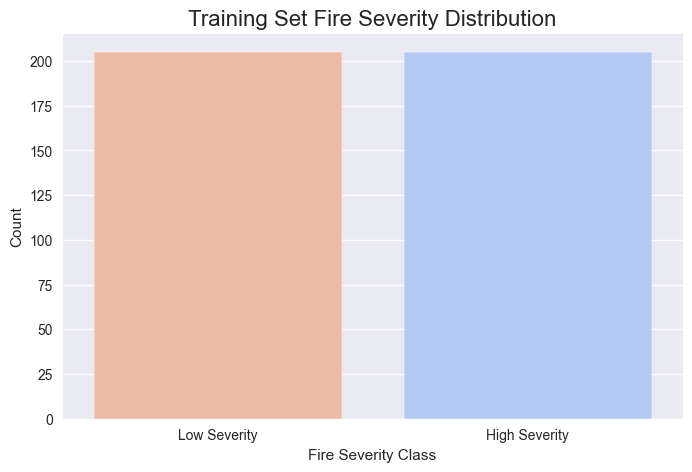

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y_train,
    hue=y_train,
    palette="coolwarm",
    order=["Low Severity", "High Severity"],
    legend=False
)

plt.title("Training Set Fire Severity Distribution", fontsize=16)
plt.xlabel("Fire Severity Class")
plt.ylabel("Count")

plt.show()

## <h2 style="color: #cb236f;">Testing set distribution</h2>

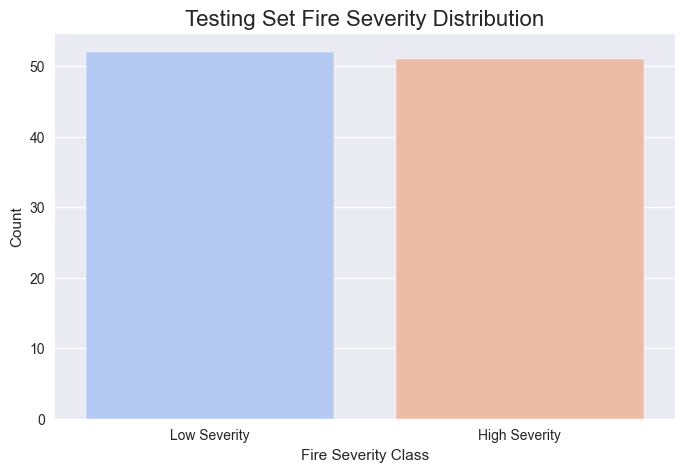

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=y_test,
    hue=y_test,
    palette="coolwarm",
    order=["Low Severity", "High Severity"],
    legend=False
)

plt.title("Testing Set Fire Severity Distribution", fontsize=16)
plt.xlabel("Fire Severity Class")
plt.ylabel("Count")

plt.show()

## <h4 style="color: #60b9e5;">Insights: </h4>

In [13]:
# Final verification before moving onto models
print("Phase 1 verification")
print("-" * 40)

print("Full dataset shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget classes:")
print(y.value_counts())

print("\nTarget inside X:", target in X.columns)

leakage_columns = [
    "fire_severity_binary",
    "wildfire_risk_binary",
    "area",
    "log_area"
]

overlap_columns = [
    "month",
    "day",
    "month_num",
    "day_num",
    "wind",
    "rain"
]

print("\nLeakage columns in X:")
print([col for col in leakage_columns if col in X.columns])

print("\nOverlapping/raw columns in X:")
print([col for col in overlap_columns if col in X.columns])

print("\nFinal feature columns:")
print(X.columns.tolist())

Phase 1 verification
----------------------------------------
Full dataset shape: (513, 14)
X shape: (513, 13)
y shape: (513,)

X_train shape: (410, 13)
X_test shape: (103, 13)
y_train shape: (410,)
y_test shape: (103,)

Target classes:
fire_severity_binary
Low Severity     257
High Severity    256
Name: count, dtype: int64

Target inside X: False

Leakage columns in X:
[]

Overlapping/raw columns in X:
[]

Final feature columns:
['x_coordinate', 'y_coordinate', 'fine_fuel_moisture_code', 'duff_moisture_code', 'drought_code', 'initial_spread_index', 'temp', 'relative_humidity', 'log_wind', 'month_sin', 'month_cos', 'day_sin', 'day_cos']


## <h2 style="color: #cb236f;">Baseline model</h2>



The baseline model provides a minimum performance benchmark.  
Here, a ⁠ DummyClassifier ⁠ is used to make simple predictions without learning patterns from the features.

All future machine learning models should perform better than this baseline.

In [14]:
from sklearn.dummy import DummyClassifier

## <h4 style="color: #6b9c80;">- Initialize </h4>

In [15]:
# Initialize baseline model
baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=RANDOM_STATE
)

# Train baseline model
baseline_model.fit(X_train, y_train)

print("Baseline Dummy Classifier trained successfully.")

Baseline Dummy Classifier trained successfully.


## <h4 style="color: #6b9c80;">- Predictions</h4>

In [16]:
y_pred_baseline = baseline_model.predict(X_test)

print("Baseline predictions generated successfully.")

Baseline predictions generated successfully.


## <h4 style="color: #6b9c80;">- Evaluate model performance</h4>

In [17]:
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

baseline_precision = precision_score(
    y_test,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="weighted",
    zero_division=0
)

baseline_macro_f1 = f1_score(
    y_test,
    y_pred_baseline,
    average="macro",
    zero_division=0
)

baseline_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_baseline
)

print("Baseline Dummy Classifier Performance")
print("-" * 45)

print(f"Accuracy          : {baseline_accuracy:.4f}")
print(f"Precision         : {baseline_precision:.4f}")
print(f"Recall            : {baseline_recall:.4f}")
print(f"Weighted F1-Score : {baseline_f1:.4f}")
print(f"Macro F1-Score    : {baseline_macro_f1:.4f}")
print(f"Balanced Accuracy : {baseline_balanced_acc:.4f}")

Baseline Dummy Classifier Performance
---------------------------------------------
Accuracy          : 0.4951
Precision         : 0.2452
Recall            : 0.4951
Weighted F1-Score : 0.3280
Macro F1-Score    : 0.3312
Balanced Accuracy : 0.5000


## <h4 style="color: #6b9c80;">- Classification Report</h4>

In [18]:
print("Baseline Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_baseline,
        zero_division=0
    )
)

Baseline Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.50      1.00      0.66        51
 Low Severity       0.00      0.00      0.00        52

     accuracy                           0.50       103
    macro avg       0.25      0.50      0.33       103
 weighted avg       0.25      0.50      0.33       103



## <h4 style="color: #6b9c80;">- Confusion Matrix</h4>

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

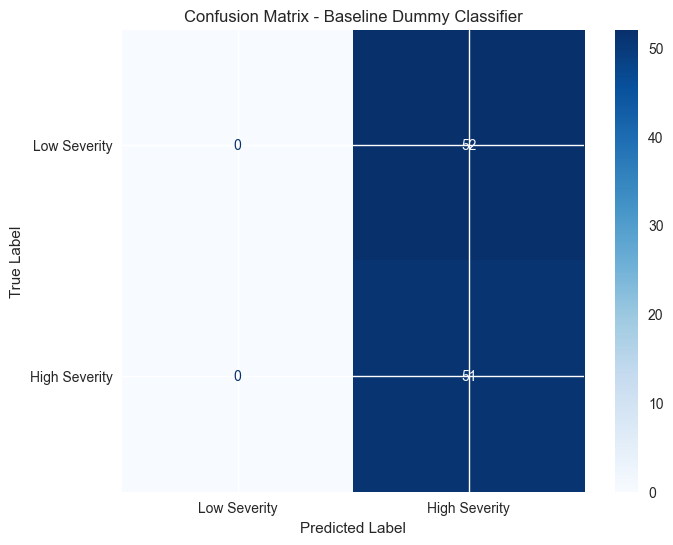

In [20]:
baseline_cm = confusion_matrix(
    y_test,
    y_pred_baseline,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Baseline Dummy Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Confusion Matrix Visualisation</h4>

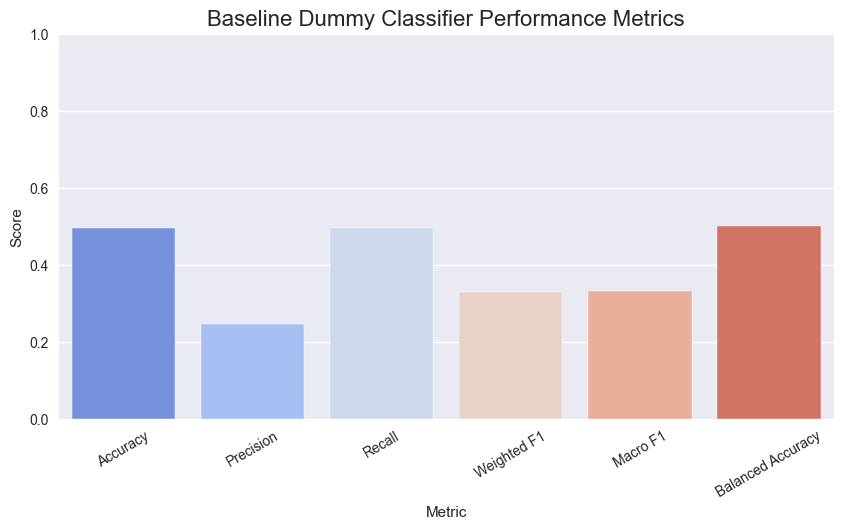

In [21]:
baseline_metrics = {
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "Weighted F1": baseline_f1,
    "Macro F1": baseline_macro_f1,
    "Balanced Accuracy": baseline_balanced_acc
}

plt.figure(figsize=(10, 5))

sns.barplot(
    x=list(baseline_metrics.keys()),
    y=list(baseline_metrics.values()),
    hue=list(baseline_metrics.keys()),
    palette="coolwarm",
    legend=False
)

plt.ylim(0, 1)

plt.title("Baseline Dummy Classifier Performance Metrics", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.show()

## <h4 style="color: #6b9c80;">- Baseline result table</h4>

In [22]:
baseline_results = pd.DataFrame({
    "Model": ["Baseline Dummy Classifier"],
    "Accuracy": [baseline_accuracy],
    "Precision": [baseline_precision],
    "Recall": [baseline_recall],
    "Weighted F1": [baseline_f1],
    "Macro F1": [baseline_macro_f1],
    "Balanced Accuracy": [baseline_balanced_acc]
})

baseline_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Baseline Dummy Classifier,0.495146,0.245169,0.495146,0.327954,0.331169,0.5


<div style="color:#60b9e5;">

## <h4>Baseline Model Insights:</h4>

•⁠  ⁠The Dummy Classifier gives a minimum benchmark for model performance.

•⁠  ⁠Since it uses the ⁠ most_frequent ⁠ strategy, it predicts only the majority class.

•⁠  ⁠Any real machine learning model should perform better than this baseline.

•⁠  ⁠Balanced Accuracy and Macro F1 are important here because they show whether both classes are being handled fairly.

</div>

## <h2 style="color: #cb236f;">Logistic Regression</h2>

Logistic Regression is used as the first real machine learning model after the Dummy Classifier baseline.

Because Logistic Regression is sensitive to feature scale, the model is built inside a pipeline with ⁠ StandardScaler ⁠.

In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## <h4 style="color: #6b9c80;">- Initialize & Train Model</h4>

In [24]:
logistic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
)

# Train model on training data
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")



Logistic Regression model trained successfully.


## <h4 style="color: #6b9c80;">- Cross Validation on training set</h4>

In [25]:
logistic_cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="balanced_accuracy"
)

print("Logistic Regression Cross-Validation Scores:")
print(logistic_cv_scores)

print("\nMean CV Balanced Accuracy:", logistic_cv_scores.mean().round(4))
print("CV Standard Deviation:", logistic_cv_scores.std().round(4))

Logistic Regression Cross-Validation Scores:
[0.51219512 0.52439024 0.46341463 0.51219512 0.46341463]

Mean CV Balanced Accuracy: 0.4951
CV Standard Deviation: 0.0263


## <h4 style="color: #6b9c80;">- Predictions</h4>

In [26]:

y_pred_logistic = logistic_model.predict(X_test)

print("Logistic Regression test predictions generated successfully.")

Logistic Regression test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Evaluate Model Performance </h4>

In [27]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

logistic_macro_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="macro",
    zero_division=0
)

logistic_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_logistic
)

print("Logistic Regression Performance")
print("-" * 45)

print(f"Accuracy          : {logistic_accuracy:.4f}")
print(f"Precision         : {logistic_precision:.4f}")
print(f"Recall            : {logistic_recall:.4f}")
print(f"Weighted F1-Score : {logistic_f1:.4f}")
print(f"Macro F1-Score    : {logistic_macro_f1:.4f}")
print(f"Balanced Accuracy : {logistic_balanced_acc:.4f}")

Logistic Regression Performance
---------------------------------------------
Accuracy          : 0.5534
Precision         : 0.5541
Recall            : 0.5534
Weighted F1-Score : 0.5529
Macro F1-Score    : 0.5530
Balanced Accuracy : 0.5537


## <h4 style="color: #6b9c80;">- Classification Report </h4>

In [30]:
print("Logistic Regression Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        zero_division=0
    )
)

Logistic Regression Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.55      0.59      0.57        51
 Low Severity       0.56      0.52      0.54        52

     accuracy                           0.55       103
    macro avg       0.55      0.55      0.55       103
 weighted avg       0.55      0.55      0.55       103



## <h4 style="color: #6b9c80;">- Confusion Matrix</h4>

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

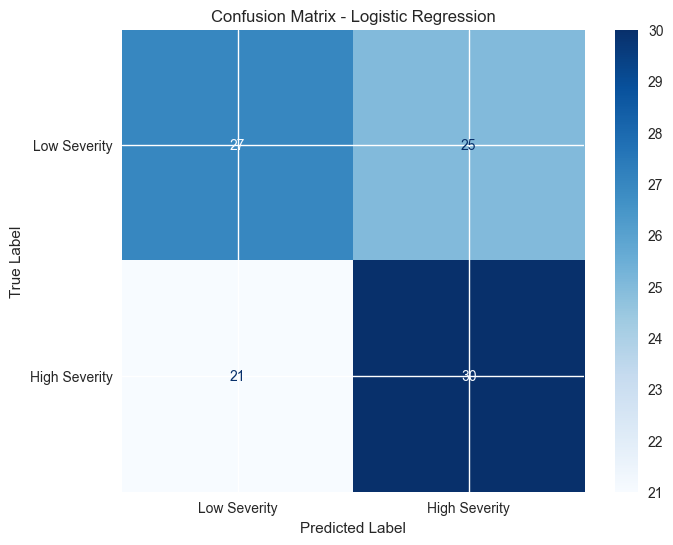

In [33]:
logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Visualize Evaluation Metrics</h4>

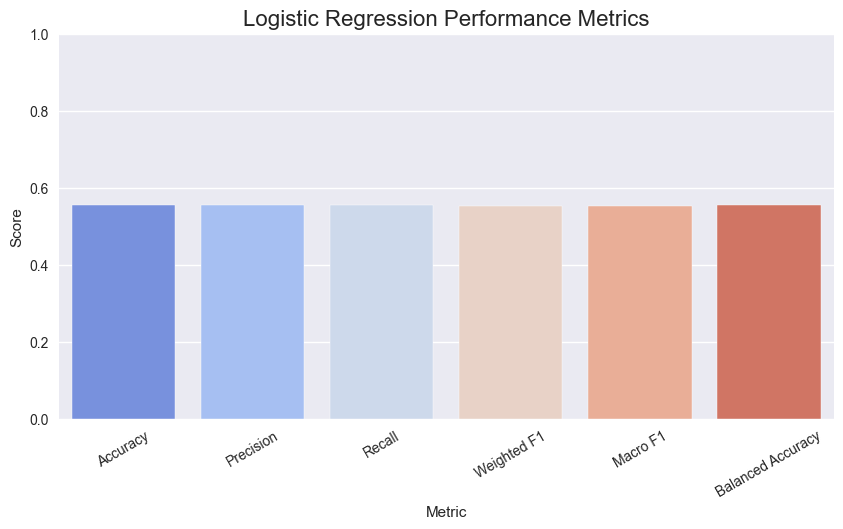

In [34]:
logistic_metrics = {
    "Accuracy": logistic_accuracy,
    "Precision": logistic_precision,
    "Recall": logistic_recall,
    "Weighted F1": logistic_f1,
    "Macro F1": logistic_macro_f1,
    "Balanced Accuracy": logistic_balanced_acc
}

plt.figure(figsize=(10, 5))

sns.barplot(
    x=list(logistic_metrics.keys()),
    y=list(logistic_metrics.values()),
    hue=list(logistic_metrics.keys()),
    palette="coolwarm",
    legend=False
)

plt.ylim(0, 1)

plt.title("Logistic Regression Performance Metrics", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.show()

## <h4 style="color: #6b9c80;">- Logistic Regression result table</h4>

In [35]:
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [logistic_accuracy],
    "Precision": [logistic_precision],
    "Recall": [logistic_recall],
    "Weighted F1": [logistic_f1],
    "Macro F1": [logistic_macro_f1],
    "Balanced Accuracy": [logistic_balanced_acc]
})

logistic_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Logistic Regression,0.553398,0.55406,0.553398,0.552892,0.553019,0.553733


## <h4 style="color: #6b9c80;">- Compare baseline vs Logistic Regression</h4>

In [36]:
baseline_vs_logistic = pd.concat(
    [baseline_results, logistic_results],
    ignore_index=True
)

baseline_vs_logistic

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Baseline Dummy Classifier,0.495146,0.245169,0.495146,0.327954,0.331169,0.500000
1,Logistic Regression,0.553398,0.554060,0.553398,0.552892,0.553019,0.553733


## <h4 style="color: #6b9c80;">- Visualise comparison</h4>

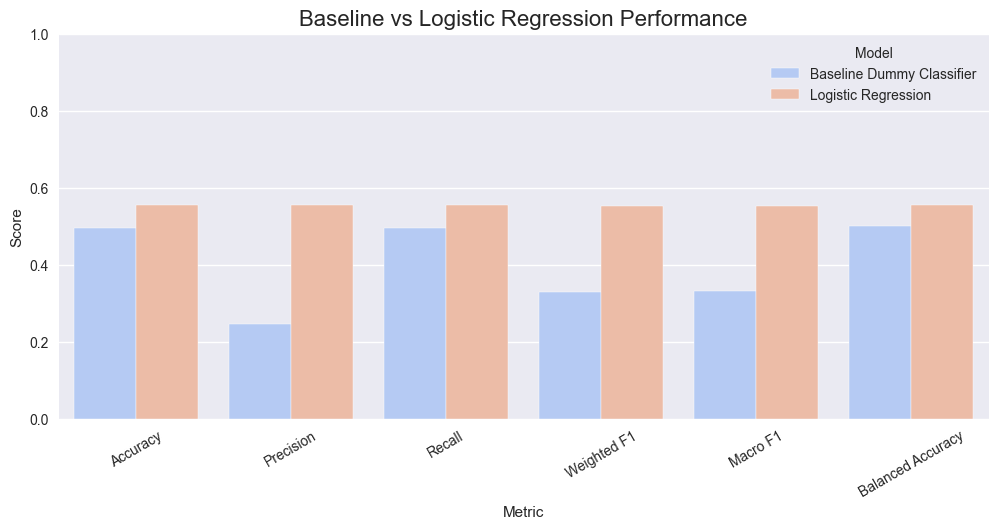

In [37]:
comparison_melted = baseline_vs_logistic.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Baseline vs Logistic Regression Performance", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model")

plt.show()

<div style="color:#60b9e5;">

## <h4>Logistic Regression Insights:</h4>

•⁠  ⁠Logistic Regression is the first real machine learning model tested after the baseline.

•⁠  ⁠The model uses scaled numerical features because Logistic Regression is sensitive to feature magnitudes.

•⁠  ⁠Performance should be compared against the Dummy Classifier baseline.

•⁠  ⁠Balanced Accuracy and Macro F1 are especially important because they show whether the model performs fairly across both fire severity classes.

•⁠  ⁠Detailed interpretation will be added after comparing all models.

</div>

## <h2 style="color: #cb236f;">Decision Tree </h2>

Decision Tree is used as the next classification model after Logistic Regression.

Unlike Logistic Regression, Decision Trees do not require feature scaling. However, they can easily overfit the training data, so both an untuned Decision Tree and a tuned Decision Tree will be tested.

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

## <h4 style="color: #6b9c80;">- Initialize & train untuned Decision Tree</h4>

In [39]:
decision_tree_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Train model on training data only
decision_tree_model.fit(X_train, y_train)

print("Untuned Decision Tree model trained successfully.")

Untuned Decision Tree model trained successfully.


## <h4 style="color: #6b9c80;">- Predictions</h4>

In [40]:
y_pred_tree = decision_tree_model.predict(X_test)

print("Untuned Decision Tree test predictions generated successfully.")

Untuned Decision Tree test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Evaluate model performance</h4>

In [41]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    average="weighted",
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    average="weighted",
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    average="weighted",
    zero_division=0
)

tree_macro_f1 = f1_score(
    y_test,
    y_pred_tree,
    average="macro",
    zero_division=0
)

tree_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_tree
)

print("Untuned Decision Tree Performance")
print("-" * 45)

print(f"Accuracy          : {tree_accuracy:.4f}")
print(f"Precision         : {tree_precision:.4f}")
print(f"Recall            : {tree_recall:.4f}")
print(f"Weighted F1-Score : {tree_f1:.4f}")
print(f"Macro F1-Score    : {tree_macro_f1:.4f}")
print(f"Balanced Accuracy : {tree_balanced_acc:.4f}")

Untuned Decision Tree Performance
---------------------------------------------
Accuracy          : 0.5146
Precision         : 0.5146
Recall            : 0.5146
Weighted F1-Score : 0.5146
Macro F1-Score    : 0.5145
Balanced Accuracy : 0.5145


## <h4 style="color: #6b9c80;">- Classification Report</h4>

In [42]:
print("Untuned Decision Tree Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_tree,
        zero_division=0
    )
)

Untuned Decision Tree Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.51      0.51      0.51        51
 Low Severity       0.52      0.52      0.52        52

     accuracy                           0.51       103
    macro avg       0.51      0.51      0.51       103
 weighted avg       0.51      0.51      0.51       103



## <h4 style="color: #6b9c80;">Confusion Matrix</h4>

In [43]:
import matplotlib.pyplot as plt

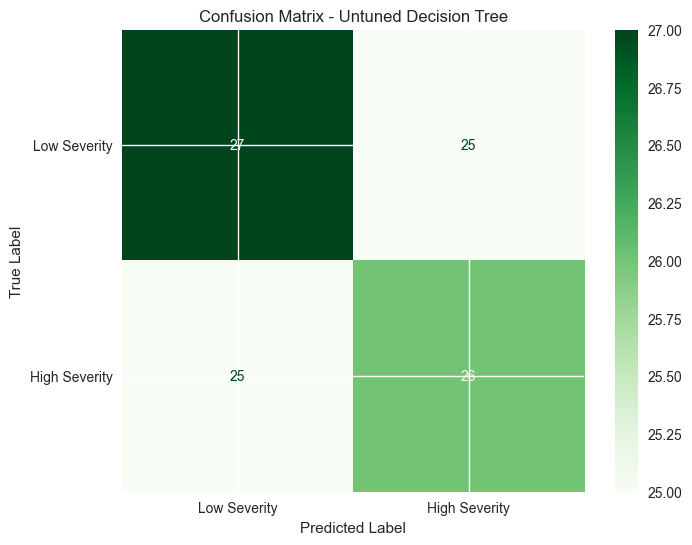

In [44]:
tree_cm = confusion_matrix(
    y_test,
    y_pred_tree,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Untuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Untuned Decision Tree result table</h4>

In [45]:
tree_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [tree_accuracy],
    "Precision": [tree_precision],
    "Recall": [tree_recall],
    "Weighted F1": [tree_f1],
    "Macro F1": [tree_macro_f1],
    "Balanced Accuracy": [tree_balanced_acc]
})

tree_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Decision Tree,0.514563,0.514563,0.514563,0.514563,0.514517,0.514517


## <h4 style="color: #6b9c80;">- Tune Decision Tree with GridSearchCV</h4>

In [46]:
decision_tree_for_tuning = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Define hyperparameter search space
tree_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}

# Initialize GridSearchCV
tree_grid_search = GridSearchCV(
    estimator=decision_tree_for_tuning,
    param_grid=tree_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

# Fit only on training data
tree_grid_search.fit(X_train, y_train)

print("Decision Tree tuning completed.")
print("\nBest Parameters:")
print(tree_grid_search.best_params_)

print("\nBest Cross-Validation Balanced Accuracy:")
print(round(tree_grid_search.best_score_, 4))

Decision Tree tuning completed.

Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}

Best Cross-Validation Balanced Accuracy:
0.5878


## <h4 style="color: #6b9c80;">- Evaluate Tuned Decision Tree </h4>

In [47]:
# Best tuned Decision Tree model
best_tree_model = tree_grid_search.best_estimator_

# Generate test predictions
y_pred_tree_tuned = best_tree_model.predict(X_test)

print("Tuned Decision Tree test predictions generated successfully.")

Tuned Decision Tree test predictions generated successfully.


In [48]:
tree_tuned_accuracy = accuracy_score(y_test, y_pred_tree_tuned)

tree_tuned_precision = precision_score(
    y_test,
    y_pred_tree_tuned,
    average="weighted",
    zero_division=0
)

tree_tuned_recall = recall_score(
    y_test,
    y_pred_tree_tuned,
    average="weighted",
    zero_division=0
)

tree_tuned_f1 = f1_score(
    y_test,
    y_pred_tree_tuned,
    average="weighted",
    zero_division=0
)

tree_tuned_macro_f1 = f1_score(
    y_test,
    y_pred_tree_tuned,
    average="macro",
    zero_division=0
)

tree_tuned_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_tree_tuned
)

print("Tuned Decision Tree Performance")
print("-" * 45)

print(f"Accuracy          : {tree_tuned_accuracy:.4f}")
print(f"Precision         : {tree_tuned_precision:.4f}")
print(f"Recall            : {tree_tuned_recall:.4f}")
print(f"Weighted F1-Score : {tree_tuned_f1:.4f}")
print(f"Macro F1-Score    : {tree_tuned_macro_f1:.4f}")
print(f"Balanced Accuracy : {tree_tuned_balanced_acc:.4f}")

Tuned Decision Tree Performance
---------------------------------------------
Accuracy          : 0.5243
Precision         : 0.5254
Recall            : 0.5243
Weighted F1-Score : 0.5224
Macro F1-Score    : 0.5227
Balanced Accuracy : 0.5249


## <h4 style="color: #6b9c80;">- Tuned Classification Report </h4>

In [49]:
print("Tuned Decision Tree Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_tree_tuned,
        zero_division=0
    )
)

Tuned Decision Tree Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.52      0.59      0.55        51
 Low Severity       0.53      0.46      0.49        52

     accuracy                           0.52       103
    macro avg       0.53      0.52      0.52       103
 weighted avg       0.53      0.52      0.52       103



## <h4 style="color: #6b9c80;">- Tuned Confusion Metrics</h4>

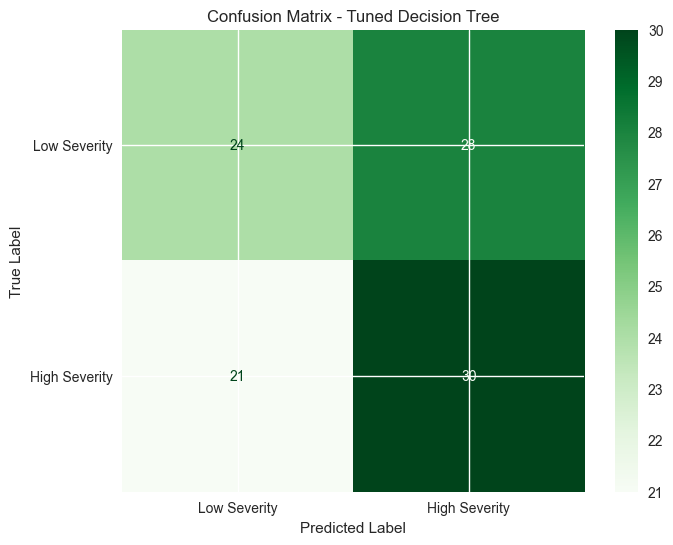

In [50]:
tree_tuned_cm = confusion_matrix(
    y_test,
    y_pred_tree_tuned,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=tree_tuned_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Greens",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Tuned result table</h4>

In [52]:
tree_tuned_results = pd.DataFrame({
    "Model": ["Tuned Decision Tree"],
    "Accuracy": [tree_tuned_accuracy],
    "Precision": [tree_tuned_precision],
    "Recall": [tree_tuned_recall],
    "Weighted F1": [tree_tuned_f1],
    "Macro F1": [tree_tuned_macro_f1],
    "Balanced Accuracy": [tree_tuned_balanced_acc]
})

tree_tuned_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Tuned Decision Tree,0.524272,0.525365,0.524272,0.522382,0.522652,0.524887


## <h4 style="color: #6b9c80;">- Compare and Visualise untuned vs tuned</h4>

In [53]:
tree_comparison = pd.concat(
    [tree_results, tree_tuned_results],
    ignore_index=True
)

tree_comparison

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Decision Tree,0.514563,0.514563,0.514563,0.514563,0.514517,0.514517
1,Tuned Decision Tree,0.524272,0.525365,0.524272,0.522382,0.522652,0.524887


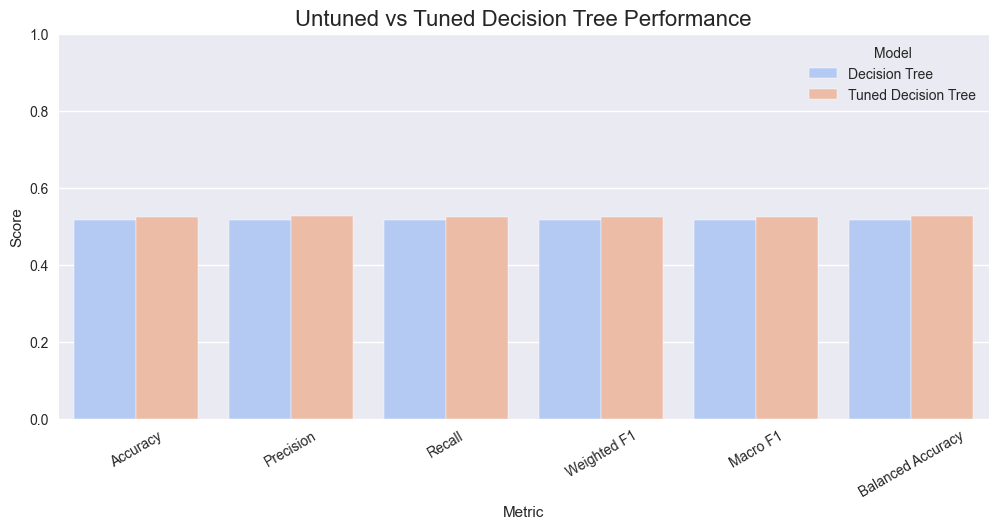

In [54]:
tree_comparison_melted = tree_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=tree_comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Untuned vs Tuned Decision Tree Performance", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model")

plt.show()

## <h4 style="color: #6b9c80;">- Did tuning help improve?</h4>

In [55]:
print("Decision Tree Tuning Check")
print("-" * 45)

print(f"Untuned Balanced Accuracy : {tree_balanced_acc:.4f}")
print(f"Tuned Balanced Accuracy   : {tree_tuned_balanced_acc:.4f}")

print(f"\nUntuned Macro F1          : {tree_macro_f1:.4f}")
print(f"Tuned Macro F1            : {tree_tuned_macro_f1:.4f}")

if tree_tuned_balanced_acc > tree_balanced_acc:
    print("\nTuning improved Balanced Accuracy.")
elif tree_tuned_balanced_acc < tree_balanced_acc:
    print("\nTuning did not improve Balanced Accuracy.")
else:
    print("\nTuning produced the same Balanced Accuracy.")

if tree_tuned_macro_f1 > tree_macro_f1:
    print("Tuning improved Macro F1.")
elif tree_tuned_macro_f1 < tree_macro_f1:
    print("Tuning did not improve Macro F1.")
else:
    print("Tuning produced the same Macro F1.")

Decision Tree Tuning Check
---------------------------------------------
Untuned Balanced Accuracy : 0.5145
Tuned Balanced Accuracy   : 0.5249

Untuned Macro F1          : 0.5145
Tuned Macro F1            : 0.5227

Tuning improved Balanced Accuracy.
Tuning improved Macro F1.


## <h4 style="color: #6b9c80;">- Feature Importance from tuned Decision Tree</h4>

In [56]:
tree_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_tree_model.feature_importances_
})

tree_feature_importance = tree_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Tuned Decision Tree Feature Importance:")
display(tree_feature_importance)

Tuned Decision Tree Feature Importance:


,Feature,Importance
4,drought_code,0.159201
6,temp,0.144907
7,relative_humidity,0.137149
3,duff_moisture_code,0.088864
5,initial_spread_index,0.083839
2,fine_fuel_moisture_code,0.083543
0,x_coordinate,0.079091
10,month_cos,0.048700
8,log_wind,0.047965
1,y_coordinate,0.047592


## <h4 style="color: #6b9c80;">- Visualise Feature Importance from tuned Decision Tree</h4>

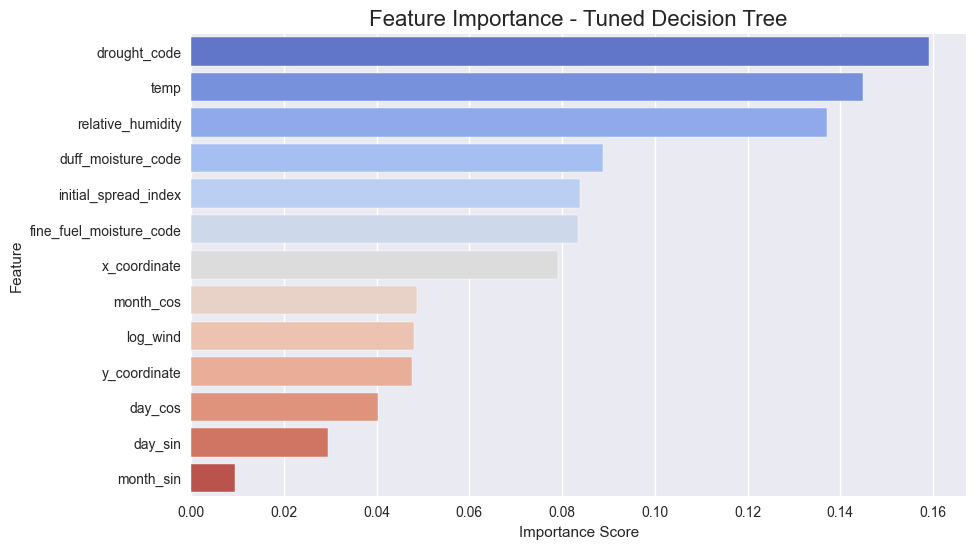

In [57]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=tree_feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="coolwarm",
    legend=False
)

plt.title("Feature Importance - Tuned Decision Tree", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## <h4 style="color: #6b9c80;">- Model comparison so far</h4>

In [58]:
model_comparison_phase_4 = pd.concat(
    [
        baseline_results,
        logistic_results,
        tree_results,
        tree_tuned_results
    ],
    ignore_index=True
)

model_comparison_phase_4

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Baseline Dummy Classifier,0.495146,0.245169,0.495146,0.327954,0.331169,0.500000
1,Logistic Regression,0.553398,0.554060,0.553398,0.552892,0.553019,0.553733
2,Decision Tree,0.514563,0.514563,0.514563,0.514563,0.514517,0.514517
3,Tuned Decision Tree,0.524272,0.525365,0.524272,0.522382,0.522652,0.524887


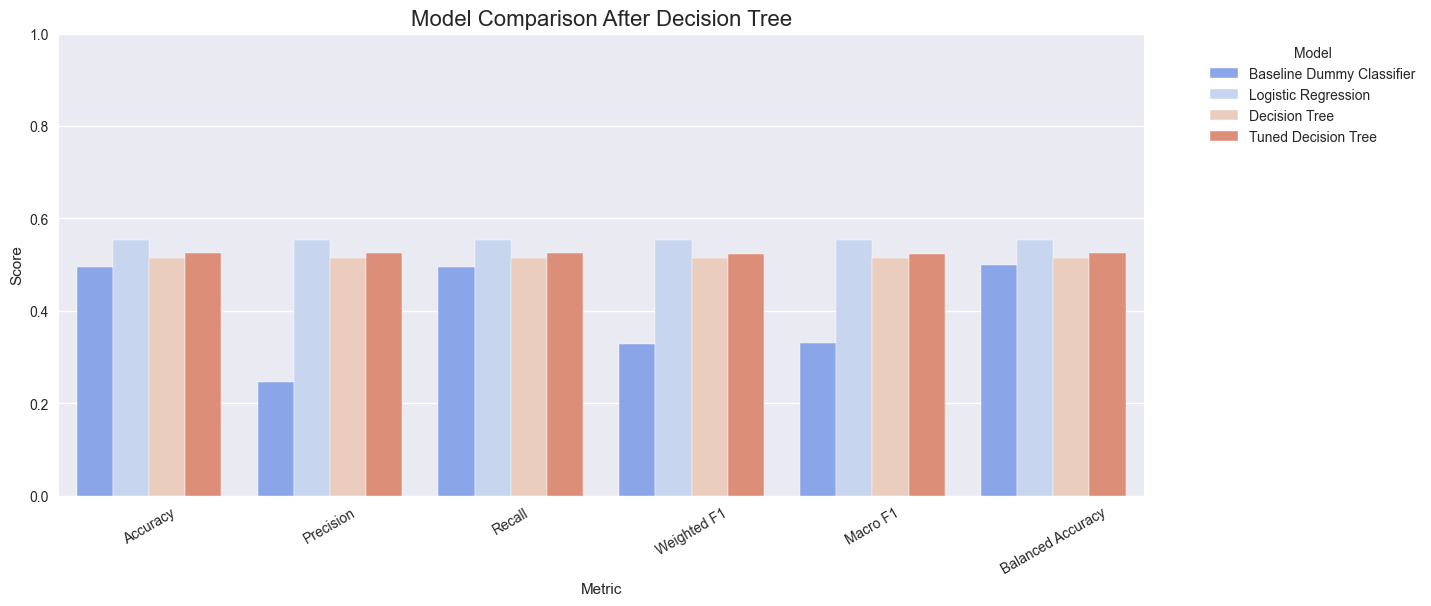

In [59]:
model_comparison_phase_4_melted = model_comparison_phase_4.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=model_comparison_phase_4_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Model Comparison After Decision Tree", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

<div style="color:#60b9e5;">

## <h4>Decision Tree Insights:</h4>

•⁠  ⁠The untuned Decision Tree provides a flexible non-linear model, but it can easily overfit.

•⁠  ⁠Hyperparameter tuning is necessary because parameters such as ⁠ max_depth ⁠, ⁠ min_samples_split ⁠, and ⁠ min_samples_leaf ⁠ control tree complexity.

•⁠  ⁠The tuned Decision Tree should be compared against the untuned Decision Tree using Balanced Accuracy and Macro F1.

•⁠  ⁠If tuning improves Balanced Accuracy or Macro F1, the tuned model should be preferred.

•⁠  ⁠Feature importance from the tuned tree helps identify which environmental variables contributed most to fire severity classification.

</div>

## <h2 style="color: #cb236f;">Random Forest Classifier</h2>

Random Forest is an ensemble model made from many Decision Trees. It usually performs better than a single Decision Tree because it reduces overfitting by combining predictions from multiple trees.

Unlike Logistic Regression, Random Forest does not require feature scaling.

## <h4 style="color: #6b9c80;">- Initialize & train untuned model</h4>

In [60]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Train model on training data only
random_forest_model.fit(X_train, y_train)

print("Untuned Random Forest model trained successfully.")

Untuned Random Forest model trained successfully.


## <h4 style="color: #6b9c80;">- Predictions</h4>

In [61]:
# Generate predictions on unseen test data
y_pred_rf = random_forest_model.predict(X_test)

print("Untuned Random Forest test predictions generated successfully.")

Untuned Random Forest test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Evaluate Untuned RandomForest performance</h4>

In [62]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_macro_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_rf
)

print("Untuned Random Forest Performance")
print("-" * 45)

print(f"Accuracy          : {rf_accuracy:.4f}")
print(f"Precision         : {rf_precision:.4f}")
print(f"Recall            : {rf_recall:.4f}")
print(f"Weighted F1-Score : {rf_f1:.4f}")
print(f"Macro F1-Score    : {rf_macro_f1:.4f}")
print(f"Balanced Accuracy : {rf_balanced_acc:.4f}")

Untuned Random Forest Performance
---------------------------------------------
Accuracy          : 0.5340
Precision         : 0.5342
Recall            : 0.5340
Weighted F1-Score : 0.5339
Macro F1-Score    : 0.5339
Balanced Accuracy : 0.5341


## <h4 style="color: #6b9c80;">- Classification Report</h4>

In [63]:
print("Untuned Random Forest Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

Untuned Random Forest Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.53      0.55      0.54        51
 Low Severity       0.54      0.52      0.53        52

     accuracy                           0.53       103
    macro avg       0.53      0.53      0.53       103
 weighted avg       0.53      0.53      0.53       103



## <h4 style="color: #6b9c80;">- Confusion Matrix</h4>

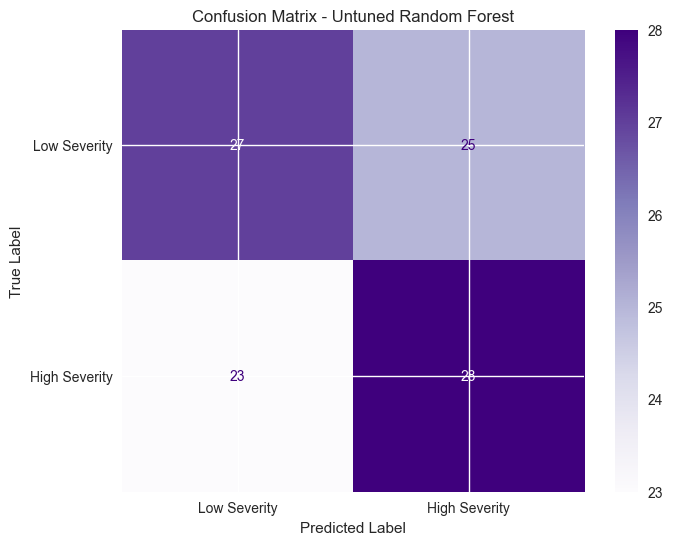

In [64]:
rf_cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Purples",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Untuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Untuned RandomForest result table</h4>

In [65]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [rf_accuracy],
    "Precision": [rf_precision],
    "Recall": [rf_recall],
    "Weighted F1": [rf_f1],
    "Macro F1": [rf_macro_f1],
    "Balanced Accuracy": [rf_balanced_acc]
})

rf_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Random Forest,0.533981,0.534208,0.533981,0.533893,0.533937,0.534125


## <h2 style="color: #cb236f;">Hyperparameter Tuning with GridSearchCV</h2>

In [66]:
# Define Random Forest model for tuning
random_forest_for_tuning = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

# Define hyperparameter search space
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Initialize GridSearchCV
rf_grid_search = GridSearchCV(
    estimator=random_forest_for_tuning,
    param_grid=rf_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

# Fit only on training data
rf_grid_search.fit(X_train, y_train)

print("Random Forest tuning completed.")
print("\nBest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation Balanced Accuracy:")
print(round(rf_grid_search.best_score_, 4))

Random Forest tuning completed.

Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation Balanced Accuracy:
0.5537


## <h4 style="color: #6b9c80;">- Evaluate tune RandomForest</h4>

In [67]:
best_rf_model = rf_grid_search.best_estimator_

# Generate test predictions
y_pred_rf_tuned = best_rf_model.predict(X_test)

print("Tuned Random Forest test predictions generated successfully.")

Tuned Random Forest test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Tuned RandomForest metrics</h4>

In [69]:
rf_tuned_accuracy = accuracy_score(y_test, y_pred_rf_tuned)

rf_tuned_precision = precision_score(
    y_test,
    y_pred_rf_tuned,
    average="weighted",
    zero_division=0
)

rf_tuned_recall = recall_score(
    y_test,
    y_pred_rf_tuned,
    average="weighted",
    zero_division=0
)

rf_tuned_f1 = f1_score(
    y_test,
    y_pred_rf_tuned,
    average="weighted",
    zero_division=0
)

rf_tuned_macro_f1 = f1_score(
    y_test,
    y_pred_rf_tuned,
    average="macro",
    zero_division=0
)

rf_tuned_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_rf_tuned
)

print("Tuned Random Forest Performance")
print("-" * 45)

print(f"Accuracy          : {rf_tuned_accuracy:.4f}")
print(f"Precision         : {rf_tuned_precision:.4f}")
print(f"Recall            : {rf_tuned_recall:.4f}")
print(f"Weighted F1-Score : {rf_tuned_f1:.4f}")
print(f"Macro F1-Score    : {rf_tuned_macro_f1:.4f}")
print(f"Balanced Accuracy : {rf_tuned_balanced_acc:.4f}")

Tuned Random Forest Performance
---------------------------------------------
Accuracy          : 0.5728
Precision         : 0.5731
Recall            : 0.5728
Weighted F1-Score : 0.5727
Macro F1-Score    : 0.5728
Balanced Accuracy : 0.5730


## <h4 style="color: #6b9c80;">- Tuned Classification Report</h4>

In [70]:
print("Tuned Random Forest Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        zero_division=0
    )
)

Tuned Random Forest Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.57      0.59      0.58        51
 Low Severity       0.58      0.56      0.57        52

     accuracy                           0.57       103
    macro avg       0.57      0.57      0.57       103
 weighted avg       0.57      0.57      0.57       103



## <h4 style="color: #6b9c80;">- Tuned Confusion metrix</h4>

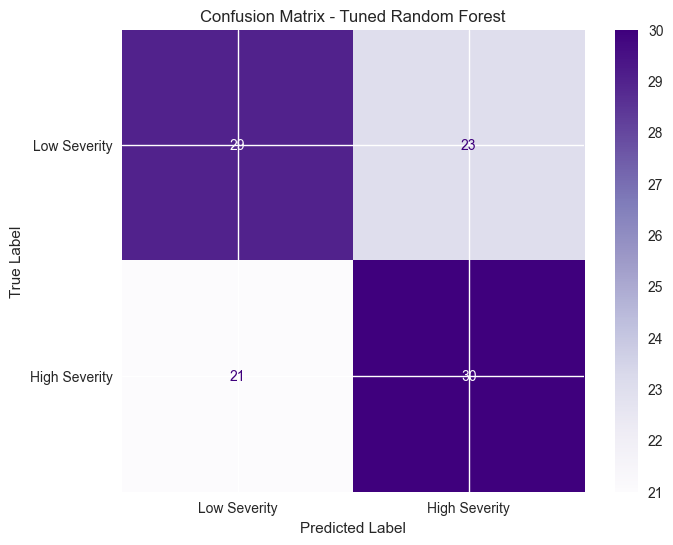

In [71]:
rf_tuned_cm = confusion_matrix(
    y_test,
    y_pred_rf_tuned,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_tuned_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Purples",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Tuned RandomForest result table</h4>

In [73]:
rf_tuned_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [rf_tuned_accuracy],
    "Precision": [rf_tuned_precision],
    "Recall": [rf_tuned_recall],
    "Weighted F1": [rf_tuned_f1],
    "Macro F1": [rf_tuned_macro_f1],
    "Balanced Accuracy": [rf_tuned_balanced_acc]
})

rf_tuned_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Tuned Random Forest,0.572816,0.573087,0.572816,0.572735,0.572775,0.572964


## <h4 style="color: #6b9c80;">- Compare untuned vs tuned & Visualise</h4>

In [74]:
rf_comparison = pd.concat(
    [rf_results, rf_tuned_results],
    ignore_index=True
)

rf_comparison

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Random Forest,0.533981,0.534208,0.533981,0.533893,0.533937,0.534125
1,Tuned Random Forest,0.572816,0.573087,0.572816,0.572735,0.572775,0.572964


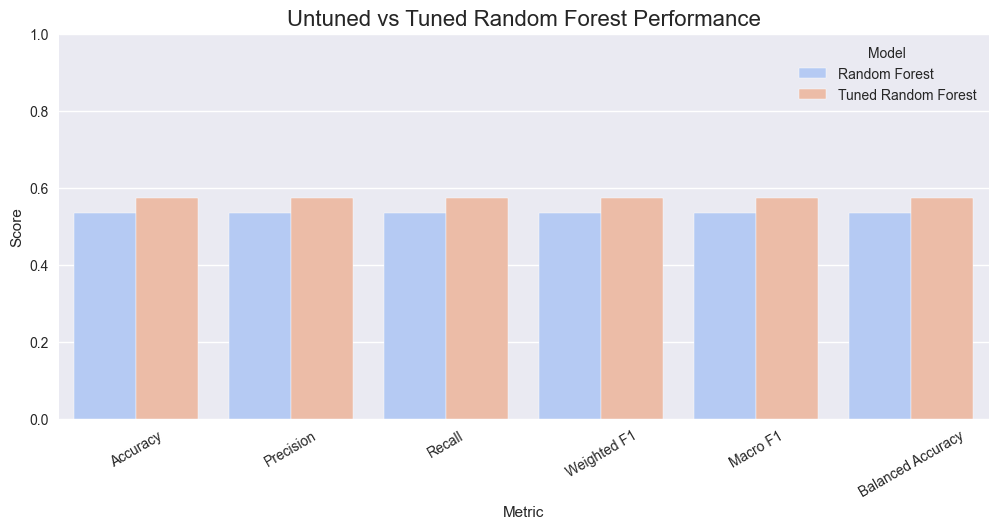

In [75]:
rf_comparison_melted = rf_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=rf_comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Untuned vs Tuned Random Forest Performance", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model")

plt.show()

## <h4 style="color: #6b9c80;">- Did tuning improve the model ?</h4>

In [76]:
print("Random Forest Tuning Check")
print("-" * 45)

print(f"Untuned Balanced Accuracy : {rf_balanced_acc:.4f}")
print(f"Tuned Balanced Accuracy   : {rf_tuned_balanced_acc:.4f}")

print(f"\nUntuned Macro F1          : {rf_macro_f1:.4f}")
print(f"Tuned Macro F1            : {rf_tuned_macro_f1:.4f}")

if rf_tuned_balanced_acc > rf_balanced_acc:
    print("\nTuning improved Balanced Accuracy.")
elif rf_tuned_balanced_acc < rf_balanced_acc:
    print("\nTuning did not improve Balanced Accuracy.")
else:
    print("\nTuning produced the same Balanced Accuracy.")

if rf_tuned_macro_f1 > rf_macro_f1:
    print("Tuning improved Macro F1.")
elif rf_tuned_macro_f1 < rf_macro_f1:
    print("Tuning did not improve Macro F1.")
else:
    print("Tuning produced the same Macro F1.")

Random Forest Tuning Check
---------------------------------------------
Untuned Balanced Accuracy : 0.5341
Tuned Balanced Accuracy   : 0.5730

Untuned Macro F1          : 0.5339
Tuned Macro F1            : 0.5728

Tuning improved Balanced Accuracy.
Tuning improved Macro F1.


## <h4 style="color: #6b9c80;">- Feature importance from tuned RandomForest</h4>

In [77]:
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Tuned Random Forest Feature Importance:")
display(rf_feature_importance)

Tuned Random Forest Feature Importance:


,Feature,Importance
6,temp,0.143903
3,duff_moisture_code,0.120648
7,relative_humidity,0.119470
4,drought_code,0.106072
5,initial_spread_index,0.096823
2,fine_fuel_moisture_code,0.089872
8,log_wind,0.082374
0,x_coordinate,0.074139
1,y_coordinate,0.040253
11,day_sin,0.038146


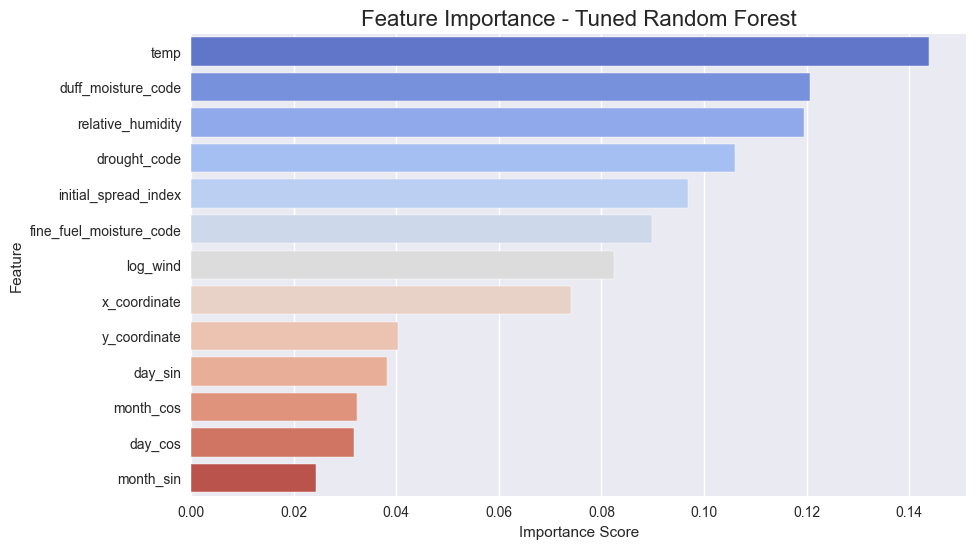

In [78]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="coolwarm",
    legend=False
)

plt.title("Feature Importance - Tuned Random Forest", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

## <h4 style="color: #6b9c80;">- Compare all models so far</h4>

In [80]:
model_comparison_phase_5 = pd.concat(
    [
        baseline_results,
        logistic_results,
        tree_results,
        tree_tuned_results,
        rf_results,
        rf_tuned_results
    ],
    ignore_index=True
)

model_comparison_phase_5

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Baseline Dummy Classifier,0.495146,0.245169,0.495146,0.327954,0.331169,0.500000
1,Logistic Regression,0.553398,0.554060,0.553398,0.552892,0.553019,0.553733
2,Decision Tree,0.514563,0.514563,0.514563,0.514563,0.514517,0.514517
3,Tuned Decision Tree,0.524272,0.525365,0.524272,0.522382,0.522652,0.524887
4,Random Forest,0.533981,0.534208,0.533981,0.533893,0.533937,0.534125
5,Tuned Random Forest,0.572816,0.573087,0.572816,0.572735,0.572775,0.572964


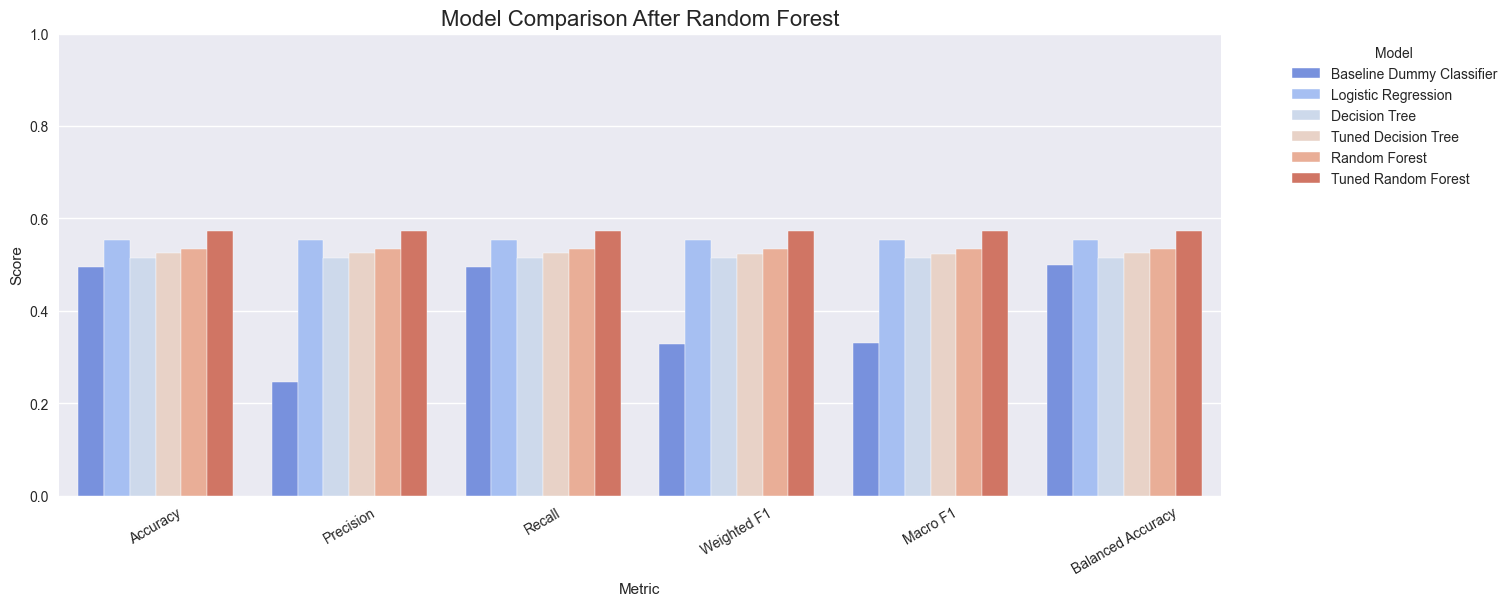

In [81]:
model_comparison_phase_5_melted = model_comparison_phase_5.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(15, 6))

sns.barplot(
    data=model_comparison_phase_5_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Model Comparison After Random Forest", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

<div style="color:#60b9e5;">

## <h4>Random Forest Insights:</h4>

•⁠  ⁠Random Forest improves on a single Decision Tree by combining many trees.

•⁠  ⁠It is less likely to overfit than an untuned Decision Tree, but tuning can still improve generalization.

•⁠  ⁠Hyperparameter tuning was performed using Balanced Accuracy to support fair performance across both severity classes.

•⁠  ⁠The tuned Random Forest should be compared with the untuned Random Forest, tuned Decision Tree, Logistic Regression, and Dummy Classifier.

•⁠  ⁠Feature importance from the tuned Random Forest helps identify which environmental variables contributed most to fire severity classification.

•⁠  ⁠Final interpretation will be written after all models are compared.

</div>

## <h2 style="color: #cb236f;">XGBoost </h2>

XGBoost is a gradient boosting model that builds trees sequentially. Each new tree attempts to correct the mistakes made by the previous trees.

Unlike Logistic Regression, XGBoost does not require feature scaling. However, the target labels are encoded into numeric values for compatibility with the model.

## <h4 style="color: #6b9c80;">- Encode Target Labels</h4>

In [82]:
xgb_label_encoder = LabelEncoder()

y_train_xgb = xgb_label_encoder.fit_transform(y_train)
y_test_xgb = xgb_label_encoder.transform(y_test)

print("XGBoost target labels encoded successfully.")
print("Class mapping:")

for class_label, encoded_value in zip(
    xgb_label_encoder.classes_,
    xgb_label_encoder.transform(xgb_label_encoder.classes_)
):
    print(f"{class_label} → {encoded_value}")

XGBoost target labels encoded successfully.
Class mapping:
High Severity → 0
Low Severity → 1


## <h4 style="color: #6b9c80;">- Initialize untuned XGBoost Model</h4>

In [83]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

# Train model on training data only
xgb_model.fit(X_train, y_train_xgb)

print("Untuned XGBoost model trained successfully.")

Untuned XGBoost model trained successfully.


## <h4 style="color: #6b9c80;">- Predictions</h4>

In [84]:
y_pred_xgb_encoded = xgb_model.predict(X_test)

# Convert encoded predictions back to original class labels
y_pred_xgb = xgb_label_encoder.inverse_transform(y_pred_xgb_encoded)

print("Untuned XGBoost test predictions generated successfully.")

Untuned XGBoost test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Evaluate untuned model performance</h4>

In [85]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="weighted",
    zero_division=0
)

xgb_macro_f1 = f1_score(
    y_test,
    y_pred_xgb,
    average="macro",
    zero_division=0
)

xgb_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_xgb
)

print("Untuned XGBoost Performance")
print("-" * 45)

print(f"Accuracy          : {xgb_accuracy:.4f}")
print(f"Precision         : {xgb_precision:.4f}")
print(f"Recall            : {xgb_recall:.4f}")
print(f"Weighted F1-Score : {xgb_f1:.4f}")
print(f"Macro F1-Score    : {xgb_macro_f1:.4f}")
print(f"Balanced Accuracy : {xgb_balanced_acc:.4f}")

Untuned XGBoost Performance
---------------------------------------------
Accuracy          : 0.5340
Precision         : 0.5340
Recall            : 0.5340
Weighted F1-Score : 0.5340
Macro F1-Score    : 0.5339
Balanced Accuracy : 0.5339


## <h4 style="color: #6b9c80;">- Classification Report</h4>

In [86]:
print("Untuned XGBoost Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_xgb,
        zero_division=0
    )
)

Untuned XGBoost Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.53      0.53      0.53        51
 Low Severity       0.54      0.54      0.54        52

     accuracy                           0.53       103
    macro avg       0.53      0.53      0.53       103
 weighted avg       0.53      0.53      0.53       103



## <h4 style="color: #6b9c80;">- Confusion Matrix</h4>

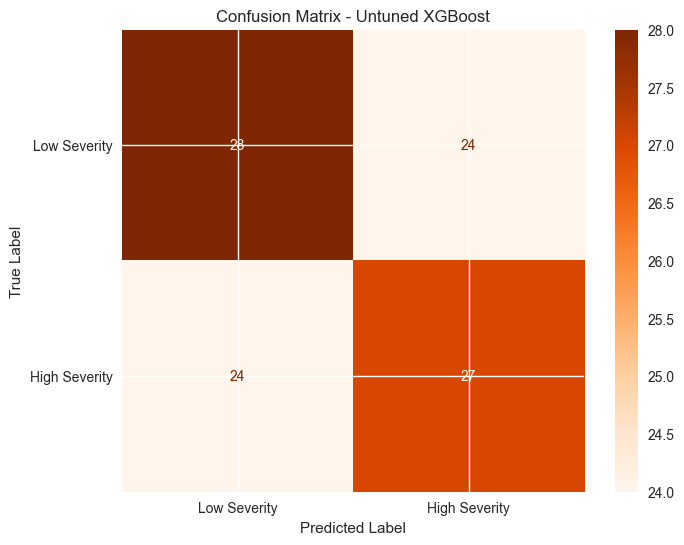

In [87]:
xgb_cm = confusion_matrix(
    y_test,
    y_pred_xgb,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Oranges",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Untuned XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Untuned XGBoost result table</h4>

In [88]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [xgb_accuracy],
    "Precision": [xgb_precision],
    "Recall": [xgb_recall],
    "Weighted F1": [xgb_f1],
    "Macro F1": [xgb_macro_f1],
    "Balanced Accuracy": [xgb_balanced_acc]
})

xgb_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,XGBoost,0.533981,0.533981,0.533981,0.533981,0.533937,0.533937


## <h4 style="color: #6b9c80;">- Hyperparameter tuning with GridSearchCV</h4>

In [89]:
# Define XGBoost model for tuning
xgb_for_tuning = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

# Define hyperparameter search space
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Initialize GridSearchCV
xgb_grid_search = GridSearchCV(
    estimator=xgb_for_tuning,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

# Fit only on training data
xgb_grid_search.fit(X_train, y_train_xgb)

print("XGBoost tuning completed.")
print("\nBest Parameters:")
print(xgb_grid_search.best_params_)

print("\nBest Cross-Validation Balanced Accuracy:")
print(round(xgb_grid_search.best_score_, 4))

XGBoost tuning completed.

Best Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}

Best Cross-Validation Balanced Accuracy:
0.5707


## <h4 style="color: #6b9c80;">- Evaluate tuned XGBoost</h4>

In [90]:
best_xgb_model = xgb_grid_search.best_estimator_

# Generate encoded test predictions
y_pred_xgb_tuned_encoded = best_xgb_model.predict(X_test)

# Convert encoded predictions back to original labels
y_pred_xgb_tuned = xgb_label_encoder.inverse_transform(
    y_pred_xgb_tuned_encoded
)

print("Tuned XGBoost test predictions generated successfully.")

Tuned XGBoost test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Tuned XGBoost Matrics</h4>

In [91]:
xgb_tuned_accuracy = accuracy_score(y_test, y_pred_xgb_tuned)

xgb_tuned_precision = precision_score(
    y_test,
    y_pred_xgb_tuned,
    average="weighted",
    zero_division=0
)

xgb_tuned_recall = recall_score(
    y_test,
    y_pred_xgb_tuned,
    average="weighted",
    zero_division=0
)

xgb_tuned_f1 = f1_score(
    y_test,
    y_pred_xgb_tuned,
    average="weighted",
    zero_division=0
)

xgb_tuned_macro_f1 = f1_score(
    y_test,
    y_pred_xgb_tuned,
    average="macro",
    zero_division=0
)

xgb_tuned_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_xgb_tuned
)

print("Tuned XGBoost Performance")
print("-" * 45)

print(f"Accuracy          : {xgb_tuned_accuracy:.4f}")
print(f"Precision         : {xgb_tuned_precision:.4f}")
print(f"Recall            : {xgb_tuned_recall:.4f}")
print(f"Weighted F1-Score : {xgb_tuned_f1:.4f}")
print(f"Macro F1-Score    : {xgb_tuned_macro_f1:.4f}")
print(f"Balanced Accuracy : {xgb_tuned_balanced_acc:.4f}")

Tuned XGBoost Performance
---------------------------------------------
Accuracy          : 0.5437
Precision         : 0.5478
Recall            : 0.5437
Weighted F1-Score : 0.5369
Macro F1-Score    : 0.5374
Balanced Accuracy : 0.5449


## <h4 style="color: #6b9c80;">- Tuned Classification Report</h4>

In [92]:
print("Tuned XGBoost Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_xgb_tuned,
        zero_division=0
    )
)

Tuned XGBoost Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.53      0.67      0.59        51
 Low Severity       0.56      0.42      0.48        52

     accuracy                           0.54       103
    macro avg       0.55      0.54      0.54       103
 weighted avg       0.55      0.54      0.54       103



## <h4 style="color: #6b9c80;">- Tuned Confusion Metrix</h4>

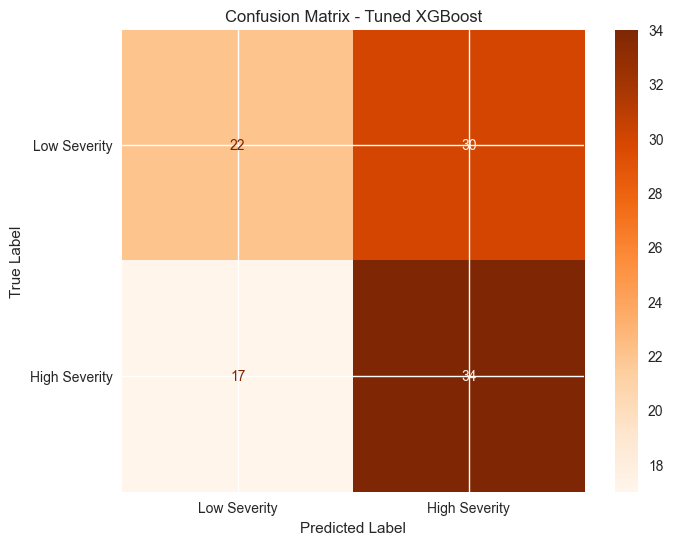

In [93]:
xgb_tuned_cm = confusion_matrix(
    y_test,
    y_pred_xgb_tuned,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_tuned_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Oranges",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Tuned XGBoost result table</h4>

In [94]:
xgb_tuned_results = pd.DataFrame({
    "Model": ["Tuned XGBoost"],
    "Accuracy": [xgb_tuned_accuracy],
    "Precision": [xgb_tuned_precision],
    "Recall": [xgb_tuned_recall],
    "Weighted F1": [xgb_tuned_f1],
    "Macro F1": [xgb_tuned_macro_f1],
    "Balanced Accuracy": [xgb_tuned_balanced_acc]
})

xgb_tuned_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Tuned XGBoost,0.543689,0.547836,0.543689,0.536887,0.53741,0.544872


## <h4 style="color: #6b9c80;">- Compare untuned vs tuned XGBoost & visualise</h4>

In [95]:
xgb_comparison = pd.concat(
    [xgb_results, xgb_tuned_results],
    ignore_index=True
)

xgb_comparison

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,XGBoost,0.533981,0.533981,0.533981,0.533981,0.533937,0.533937
1,Tuned XGBoost,0.543689,0.547836,0.543689,0.536887,0.537410,0.544872


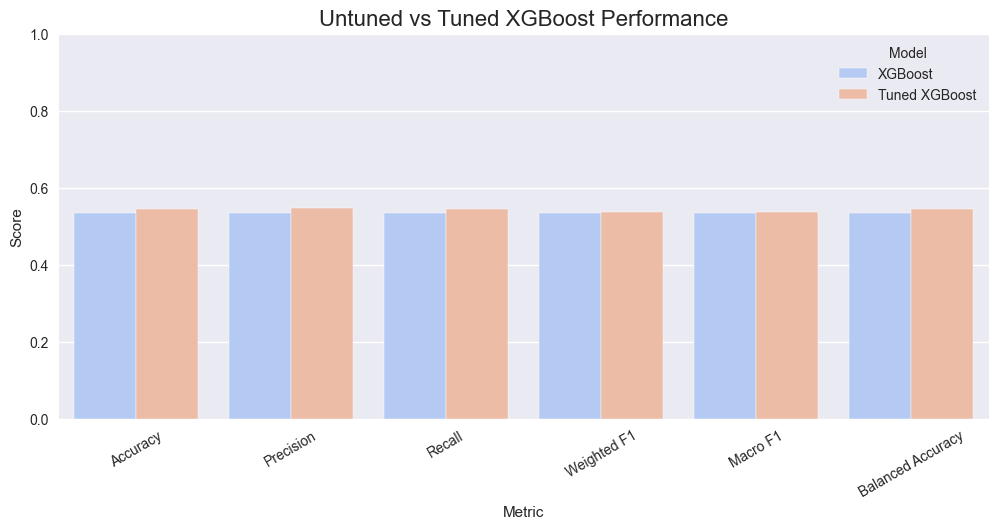

In [96]:
xgb_comparison_melted = xgb_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=xgb_comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Untuned vs Tuned XGBoost Performance", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model")

plt.show()

## <h4 style="color: #6b9c80;">- Did tuning improve the model?</h4>

In [97]:
print("XGBoost Tuning Check")
print("-" * 45)

print(f"Untuned Balanced Accuracy : {xgb_balanced_acc:.4f}")
print(f"Tuned Balanced Accuracy   : {xgb_tuned_balanced_acc:.4f}")

print(f"\nUntuned Macro F1          : {xgb_macro_f1:.4f}")
print(f"Tuned Macro F1            : {xgb_tuned_macro_f1:.4f}")

if xgb_tuned_balanced_acc > xgb_balanced_acc:
    print("\nTuning improved Balanced Accuracy.")
elif xgb_tuned_balanced_acc < xgb_balanced_acc:
    print("\nTuning did not improve Balanced Accuracy.")
else:
    print("\nTuning produced the same Balanced Accuracy.")

if xgb_tuned_macro_f1 > xgb_macro_f1:
    print("Tuning improved Macro F1.")
elif xgb_tuned_macro_f1 < xgb_macro_f1:
    print("Tuning did not improve Macro F1.")
else:
    print("Tuning produced the same Macro F1.")

XGBoost Tuning Check
---------------------------------------------
Untuned Balanced Accuracy : 0.5339
Tuned Balanced Accuracy   : 0.5449

Untuned Macro F1          : 0.5339
Tuned Macro F1            : 0.5374

Tuning improved Balanced Accuracy.
Tuning improved Macro F1.


## <h4 style="color: #6b9c80;">- Feature Importance from tuned XGBoost</h4>

In [98]:
xgb_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb_model.feature_importances_
})

xgb_feature_importance = xgb_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Tuned XGBoost Feature Importance:")
display(xgb_feature_importance)

Tuned XGBoost Feature Importance:


,Feature,Importance
0,x_coordinate,0.184737
3,duff_moisture_code,0.138277
6,temp,0.123174
7,relative_humidity,0.110044
5,initial_spread_index,0.107472
1,y_coordinate,0.089639
4,drought_code,0.086799
8,log_wind,0.078938
12,day_cos,0.037664
2,fine_fuel_moisture_code,0.030355


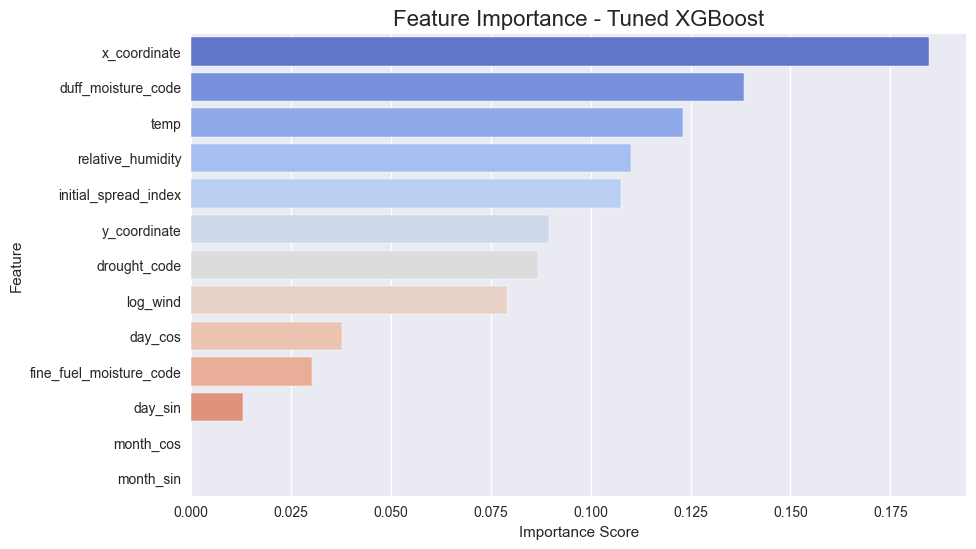

In [99]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="coolwarm",
    legend=False
)

plt.title("Feature Importance - Tuned XGBoost", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()


## <h4 style="color: #6b9c80;">- Compare all models so far</h4>

In [100]:
model_comparison_phase_6 = pd.concat(
    [
        baseline_results,
        logistic_results,
        tree_results,
        tree_tuned_results,
        rf_results,
        rf_tuned_results,
        xgb_results,
        xgb_tuned_results
    ],
    ignore_index=True
)

model_comparison_phase_6

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Baseline Dummy Classifier,0.495146,0.245169,0.495146,0.327954,0.331169,0.500000
1,Logistic Regression,0.553398,0.554060,0.553398,0.552892,0.553019,0.553733
2,Decision Tree,0.514563,0.514563,0.514563,0.514563,0.514517,0.514517
3,Tuned Decision Tree,0.524272,0.525365,0.524272,0.522382,0.522652,0.524887
4,Random Forest,0.533981,0.534208,0.533981,0.533893,0.533937,0.534125
5,Tuned Random Forest,0.572816,0.573087,0.572816,0.572735,0.572775,0.572964
6,XGBoost,0.533981,0.533981,0.533981,0.533981,0.533937,0.533937
7,Tuned XGBoost,0.543689,0.547836,0.543689,0.536887,0.537410,0.544872


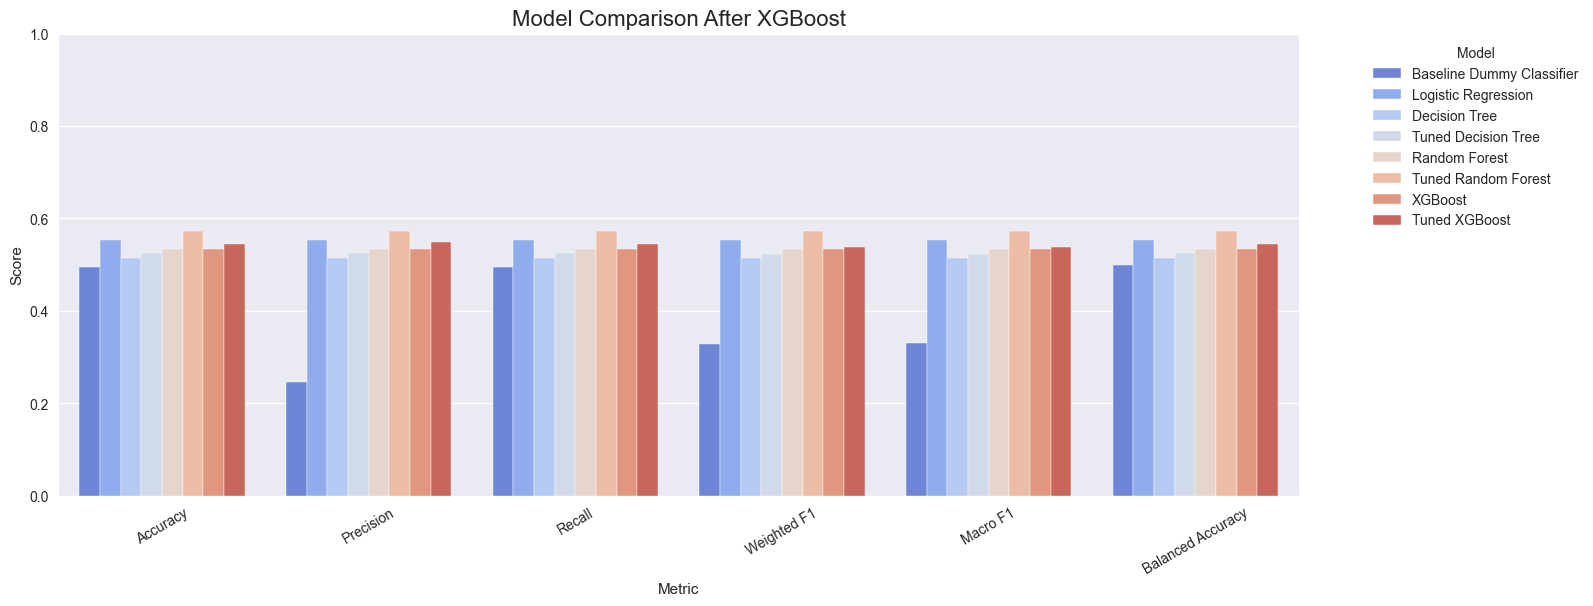

In [101]:
model_comparison_phase_6_melted = model_comparison_phase_6.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(16, 6))

sns.barplot(
    data=model_comparison_phase_6_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Model Comparison After XGBoost", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

<div style="color:#60b9e5;">

## <h4>XGBoost Insights:</h4>

•⁠  ⁠XGBoost is a strong ensemble model that builds trees sequentially to correct previous errors.

•⁠  ⁠Target labels were encoded into numeric values for compatibility with XGBoost.

•⁠  ⁠Hyperparameter tuning was performed using Balanced Accuracy to support fair performance across both fire severity classes.

•⁠  ⁠The tuned XGBoost model should be compared with the untuned XGBoost, tuned Random Forest, tuned Decision Tree, Logistic Regression, and Dummy Classifier.

•⁠  ⁠Feature importance from the tuned XGBoost model helps identify which variables contributed most to classification.

•⁠  ⁠Final interpretation will be written after all models are compared.

</div>




## <h2 style="color: #cb236f;">MLP Classifier (Neural Network)</h2>

The MLP Classifier is a simple feed-forward neural network.

Unlike Decision Tree, Random Forest, and XGBoost, MLP is sensitive to feature scale. Therefore, the model is built inside a pipeline with ⁠ StandardScaler ⁠.

In [102]:
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
import warnings

## <h4 style="color: #6b9c80;">- Initialise & train untuned MLP</h4>

In [103]:
# Suppress convergence warnings for cleaner notebook output
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Initialize untuned MLP pipeline
mlp_model = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=1000,
        random_state=RANDOM_STATE
    )
)

# Train model on training data only
mlp_model.fit(X_train, y_train)

print("Untuned MLP Classifier trained successfully.")

Untuned MLP Classifier trained successfully.


## <h4 style="color: #6b9c80;">- Predictions</h4>

In [104]:
y_pred_mlp = mlp_model.predict(X_test)

print("Untuned MLP test predictions generated successfully.")

Untuned MLP test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Evaluate untuned MLP performance</h4>

In [106]:
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

mlp_precision = precision_score(
    y_test,
    y_pred_mlp,
    average="weighted",
    zero_division=0
)

mlp_recall = recall_score(
    y_test,
    y_pred_mlp,
    average="weighted",
    zero_division=0
)

mlp_f1 = f1_score(
    y_test,
    y_pred_mlp,
    average="weighted",
    zero_division=0
)

mlp_macro_f1 = f1_score(
    y_test,
    y_pred_mlp,
    average="macro",
    zero_division=0
)

mlp_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_mlp
)

print("Untuned MLP Classifier Performance")
print("-" * 45)

print(f"Accuracy          : {mlp_accuracy:.4f}")
print(f"Precision         : {mlp_precision:.4f}")
print(f"Recall            : {mlp_recall:.4f}")
print(f"Weighted F1-Score : {mlp_f1:.4f}")
print(f"Macro F1-Score    : {mlp_macro_f1:.4f}")
print(f"Balanced Accuracy : {mlp_balanced_acc:.4f}")

Untuned MLP Classifier Performance
---------------------------------------------
Accuracy          : 0.5146
Precision         : 0.5148
Recall            : 0.5146
Weighted F1-Score : 0.5145
Macro F1-Score    : 0.5145
Balanced Accuracy : 0.5147


## <h4 style="color: #6b9c80;">- Classification Report</h4>

In [107]:
print("Untuned MLP Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_mlp,
        zero_division=0
    )
)

Untuned MLP Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.51      0.53      0.52        51
 Low Severity       0.52      0.50      0.51        52

     accuracy                           0.51       103
    macro avg       0.51      0.51      0.51       103
 weighted avg       0.51      0.51      0.51       103



## <h4 style="color: #6b9c80;">- Confusion Matrix</h4>

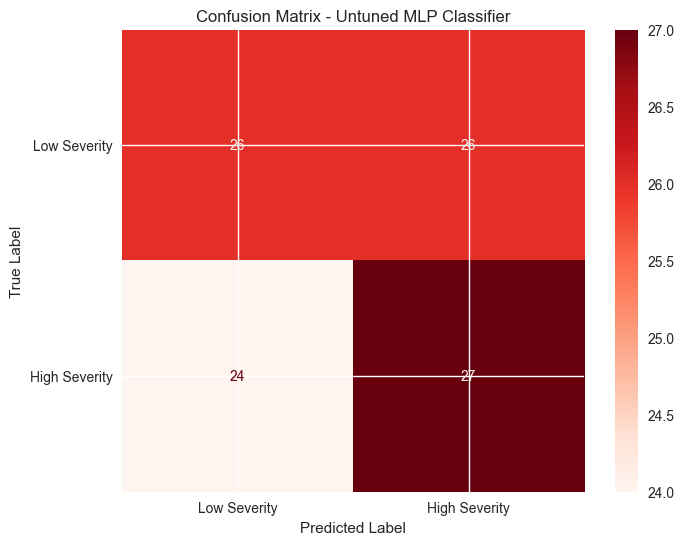

In [108]:
mlp_cm = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mlp_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Reds",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Untuned MLP Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Untuned MLP result table</h4>

In [110]:
mlp_results = pd.DataFrame({
    "Model": ["MLP Classifier"],
    "Accuracy": [mlp_accuracy],
    "Precision": [mlp_precision],
    "Recall": [mlp_recall],
    "Weighted F1": [mlp_f1],
    "Macro F1": [mlp_macro_f1],
    "Balanced Accuracy": [mlp_balanced_acc]
})

mlp_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706


## <h4 style="color: #6b9c80;">- Hyperparameter Tuning ith GridSearchCV</h4>

In [111]:
# Define MLP pipeline for tuning
mlp_pipeline_for_tuning = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        max_iter=1000,
        random_state=RANDOM_STATE
    )
)

# Define hyperparameter search space
mlp_param_grid = {
    "mlpclassifier__hidden_layer_sizes": [
        (32,),
        (64,),
        (64, 32),
        (100,)
    ],
    "mlpclassifier__activation": [
        "relu",
        "tanh"
    ],
    "mlpclassifier__alpha": [
        0.0001,
        0.001,
        0.01
    ],
    "mlpclassifier__learning_rate_init": [
        0.001,
        0.01
    ]
}

# Initialize GridSearchCV
mlp_grid_search = GridSearchCV(
    estimator=mlp_pipeline_for_tuning,
    param_grid=mlp_param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

# Fit only on training data
mlp_grid_search.fit(X_train, y_train)

print("MLP tuning completed.")
print("\nBest Parameters:")
print(mlp_grid_search.best_params_)

print("\nBest Cross-Validation Balanced Accuracy:")
print(round(mlp_grid_search.best_score_, 4))

MLP tuning completed.

Best Parameters:
{'mlpclassifier__activation': 'relu', 'mlpclassifier__alpha': 0.01, 'mlpclassifier__hidden_layer_sizes': (64,), 'mlpclassifier__learning_rate_init': 0.001}

Best Cross-Validation Balanced Accuracy:
0.578


## <h4 style="color: #6b9c80;">- Evaluate tuned MLP</h4>

In [113]:
best_mlp_model = mlp_grid_search.best_estimator_

# Generate test predictions
y_pred_mlp_tuned = best_mlp_model.predict(X_test)

print("Tuned MLP test predictions generated successfully.")

Tuned MLP test predictions generated successfully.


## <h4 style="color: #6b9c80;">- Tuned MLP metrics</h4>

In [114]:
mlp_tuned_accuracy = accuracy_score(y_test, y_pred_mlp_tuned)

mlp_tuned_precision = precision_score(
    y_test,
    y_pred_mlp_tuned,
    average="weighted",
    zero_division=0
)

mlp_tuned_recall = recall_score(
    y_test,
    y_pred_mlp_tuned,
    average="weighted",
    zero_division=0
)

mlp_tuned_f1 = f1_score(
    y_test,
    y_pred_mlp_tuned,
    average="weighted",
    zero_division=0
)

mlp_tuned_macro_f1 = f1_score(
    y_test,
    y_pred_mlp_tuned,
    average="macro",
    zero_division=0
)

mlp_tuned_balanced_acc = balanced_accuracy_score(
    y_test,
    y_pred_mlp_tuned
)

print("Tuned MLP Classifier Performance")
print("-" * 45)

print(f"Accuracy          : {mlp_tuned_accuracy:.4f}")
print(f"Precision         : {mlp_tuned_precision:.4f}")
print(f"Recall            : {mlp_tuned_recall:.4f}")
print(f"Weighted F1-Score : {mlp_tuned_f1:.4f}")
print(f"Macro F1-Score    : {mlp_tuned_macro_f1:.4f}")
print(f"Balanced Accuracy : {mlp_tuned_balanced_acc:.4f}")

Tuned MLP Classifier Performance
---------------------------------------------
Accuracy          : 0.5146
Precision         : 0.5148
Recall            : 0.5146
Weighted F1-Score : 0.5145
Macro F1-Score    : 0.5145
Balanced Accuracy : 0.5147


## <h4 style="color: #6b9c80;">- Tuned Classification Report</h4>

In [115]:
print("Tuned MLP Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_mlp_tuned,
        zero_division=0
    )
)

Tuned MLP Classification Report
---------------------------------------------
               precision    recall  f1-score   support

High Severity       0.51      0.53      0.52        51
 Low Severity       0.52      0.50      0.51        52

     accuracy                           0.51       103
    macro avg       0.51      0.51      0.51       103
 weighted avg       0.51      0.51      0.51       103



## <h4 style="color: #6b9c80;">- Tuned Confusion matrix</h4>

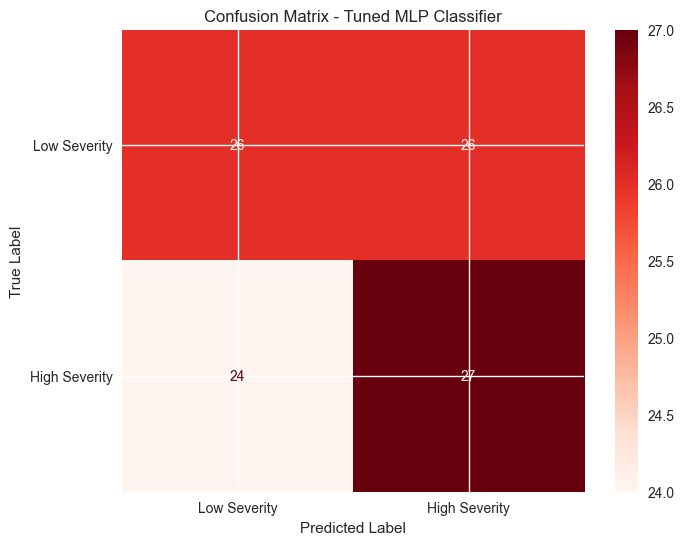

In [116]:
mlp_tuned_cm = confusion_matrix(
    y_test,
    y_pred_mlp_tuned,
    labels=["Low Severity", "High Severity"]
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=mlp_tuned_cm,
    display_labels=["Low Severity", "High Severity"]
)

disp.plot(
    cmap="Reds",
    ax=ax,
    colorbar=True
)

plt.title("Confusion Matrix - Tuned MLP Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## <h4 style="color: #6b9c80;">- Tuned MLP result table</h4>

In [117]:
mlp_tuned_results = pd.DataFrame({
    "Model": ["Tuned MLP Classifier"],
    "Accuracy": [mlp_tuned_accuracy],
    "Precision": [mlp_tuned_precision],
    "Recall": [mlp_tuned_recall],
    "Weighted F1": [mlp_tuned_f1],
    "Macro F1": [mlp_tuned_macro_f1],
    "Balanced Accuracy": [mlp_tuned_balanced_acc]
})

mlp_tuned_results

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Tuned MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706


## <h4 style="color: #6b9c80;">- Compare untuned vs tuned MLP & visualise</h4>

In [118]:
mlp_comparison = pd.concat(
    [mlp_results, mlp_tuned_results],
    ignore_index=True
)

mlp_comparison

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706
1,Tuned MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706


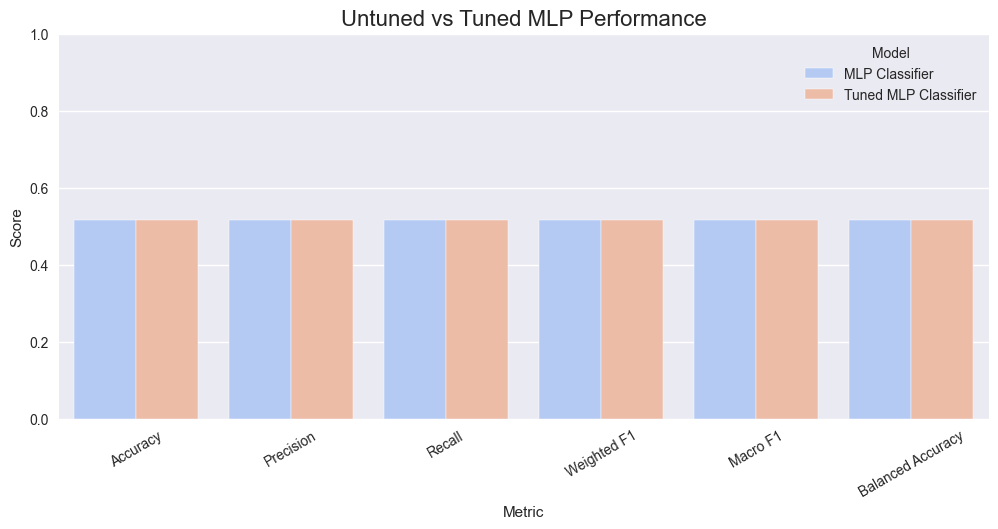

In [119]:
mlp_comparison_melted = mlp_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=mlp_comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Untuned vs Tuned MLP Performance", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model")

plt.show()

## <h4 style="color: #6b9c80;">- did the model improve?</h4>

In [120]:
print("MLP Tuning Check")
print("-" * 45)

print(f"Untuned Balanced Accuracy : {mlp_balanced_acc:.4f}")
print(f"Tuned Balanced Accuracy   : {mlp_tuned_balanced_acc:.4f}")

print(f"\nUntuned Macro F1          : {mlp_macro_f1:.4f}")
print(f"Tuned Macro F1            : {mlp_tuned_macro_f1:.4f}")

if mlp_tuned_balanced_acc > mlp_balanced_acc:
    print("\nTuning improved Balanced Accuracy.")
elif mlp_tuned_balanced_acc < mlp_balanced_acc:
    print("\nTuning did not improve Balanced Accuracy.")
else:
    print("\nTuning produced the same Balanced Accuracy.")

if mlp_tuned_macro_f1 > mlp_macro_f1:
    print("Tuning improved Macro F1.")
elif mlp_tuned_macro_f1 < mlp_macro_f1:
    print("Tuning did not improve Macro F1.")
else:
    print("Tuning produced the same Macro F1.")

MLP Tuning Check
---------------------------------------------
Untuned Balanced Accuracy : 0.5147
Tuned Balanced Accuracy   : 0.5147

Untuned Macro F1          : 0.5145
Tuned Macro F1            : 0.5145

Tuning produced the same Balanced Accuracy.
Tuning produced the same Macro F1.


## <h4 style="color: #6b9c80;">-Compare all models so far</h4>

In [121]:
model_comparison_phase_7 = pd.concat(
    [
        baseline_results,
        logistic_results,
        tree_results,
        tree_tuned_results,
        rf_results,
        rf_tuned_results,
        xgb_results,
        xgb_tuned_results,
        mlp_results,
        mlp_tuned_results
    ],
    ignore_index=True
)

model_comparison_phase_7

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Baseline Dummy Classifier,0.495146,0.245169,0.495146,0.327954,0.331169,0.500000
1,Logistic Regression,0.553398,0.554060,0.553398,0.552892,0.553019,0.553733
2,Decision Tree,0.514563,0.514563,0.514563,0.514563,0.514517,0.514517
3,Tuned Decision Tree,0.524272,0.525365,0.524272,0.522382,0.522652,0.524887
4,Random Forest,0.533981,0.534208,0.533981,0.533893,0.533937,0.534125
5,Tuned Random Forest,0.572816,0.573087,0.572816,0.572735,0.572775,0.572964
6,XGBoost,0.533981,0.533981,0.533981,0.533981,0.533937,0.533937
7,Tuned XGBoost,0.543689,0.547836,0.543689,0.536887,0.537410,0.544872
8,MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706
9,Tuned MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706


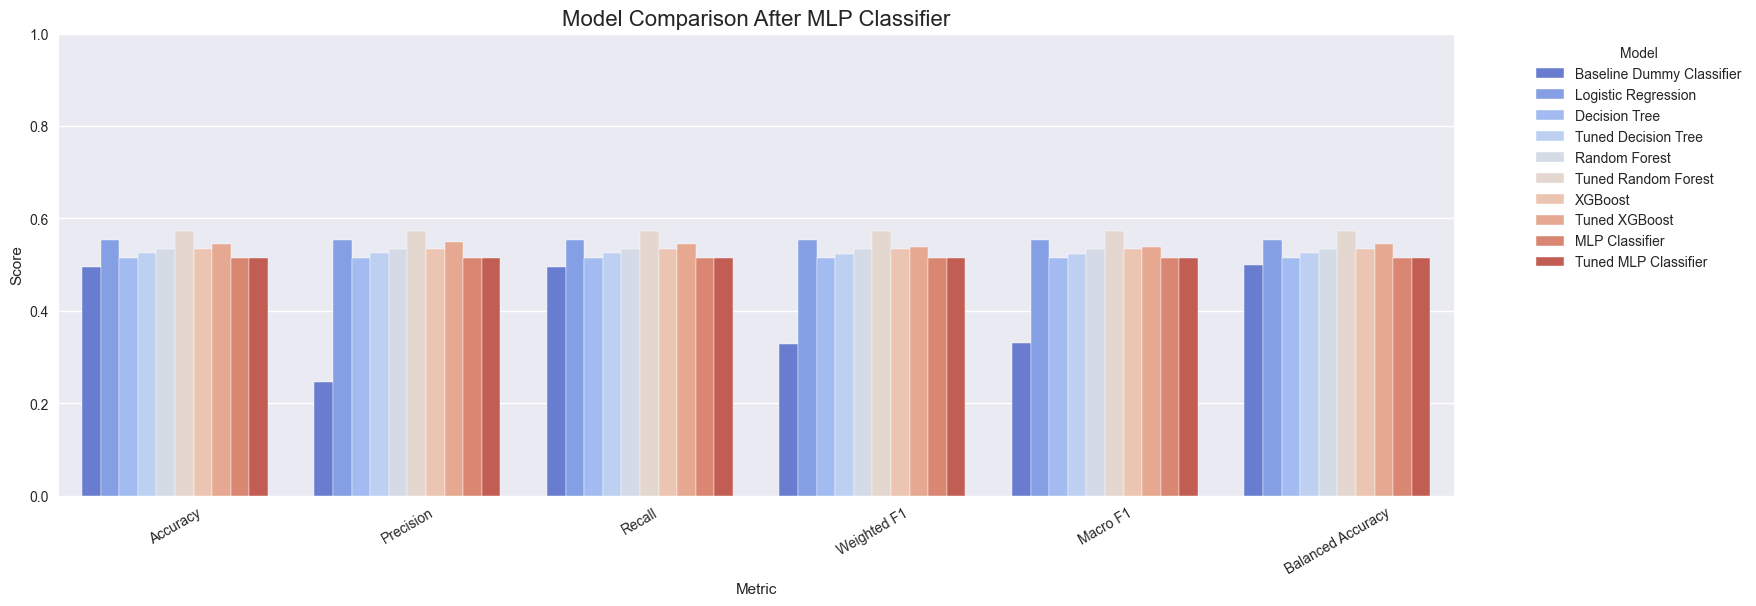

In [122]:
model_comparison_phase_7_melted = model_comparison_phase_7.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(18, 6))

sns.barplot(
    data=model_comparison_phase_7_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Model Comparison After MLP Classifier", fontsize=16)
plt.xlabel("Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

<div style="color:#60b9e5;">

## <h4>MLP Classifier Insights:</h4>

•⁠  ⁠MLP is a neural-network-based classifier and requires scaled input features.

•⁠  ⁠A ⁠ StandardScaler ⁠ was used inside a pipeline to avoid data leakage.

•⁠  ⁠Hyperparameter tuning was performed using Balanced Accuracy to support fair performance across both fire severity classes.

•⁠  ⁠Since the dataset is relatively small, the MLP may not necessarily outperform tree-based models.

•⁠  ⁠The tuned MLP should be compared against XGBoost, Random Forest, Decision Tree, Logistic Regression, and the Dummy Classifier baseline.

•⁠  ⁠Final interpretation will be written after the complete model comparison.

</div>

## <h2 style="color: #cb236f;">Final Model Comparison</h2>

All models are compared using the same train-test split and the same evaluation metrics.

The main metric used for final model selection is ⁠ Balanced Accuracy ⁠, followed by ⁠ Macro F1 ⁠. These metrics are more useful than plain accuracy because they evaluate whether the model performs fairly across both fire severity classes.

In [123]:
final_model_comparison = pd.concat(
    [
        baseline_results,
        logistic_results,
        tree_results,
        tree_tuned_results,
        rf_results,
        rf_tuned_results,
        xgb_results,
        xgb_tuned_results,
        mlp_results,
        mlp_tuned_results
    ],
    ignore_index=True
)

# Sort models by the most important metrics
final_model_comparison = final_model_comparison.sort_values(
    by=["Balanced Accuracy", "Macro F1", "Weighted F1"],
    ascending=False
).reset_index(drop=True)

final_model_comparison

,Model,Accuracy,Precision,Recall,Weighted F1,Macro F1,Balanced Accuracy
0,Tuned Random Forest,0.572816,0.573087,0.572816,0.572735,0.572775,0.572964
1,Logistic Regression,0.553398,0.554060,0.553398,0.552892,0.553019,0.553733
2,Tuned XGBoost,0.543689,0.547836,0.543689,0.536887,0.537410,0.544872
3,Random Forest,0.533981,0.534208,0.533981,0.533893,0.533937,0.534125
4,XGBoost,0.533981,0.533981,0.533981,0.533981,0.533937,0.533937
5,Tuned Decision Tree,0.524272,0.525365,0.524272,0.522382,0.522652,0.524887
6,MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706
7,Tuned MLP Classifier,0.514563,0.514768,0.514563,0.514472,0.514517,0.514706
8,Decision Tree,0.514563,0.514563,0.514563,0.514563,0.514517,0.514517
9,Baseline Dummy Classifier,0.495146,0.245169,0.495146,0.327954,0.331169,0.500000


## <h4 style="color: #6b9c80;">- Best Model Selection</h4>

In [124]:
best_model_row = final_model_comparison.iloc[0]

best_model_name = best_model_row["Model"]
best_balanced_accuracy = best_model_row["Balanced Accuracy"]
best_macro_f1 = best_model_row["Macro F1"]
best_weighted_f1 = best_model_row["Weighted F1"]

print("Best Model Selected")
print("-" * 45)

print(f"Best Model        : {best_model_name}")
print(f"Balanced Accuracy : {best_balanced_accuracy:.4f}")
print(f"Macro F1          : {best_macro_f1:.4f}")
print(f"Weighted F1       : {best_weighted_f1:.4f}")

Best Model Selected
---------------------------------------------
Best Model        : Tuned Random Forest
Balanced Accuracy : 0.5730
Macro F1          : 0.5728
Weighted F1       : 0.5727


## <h4 style="color: #6b9c80;">- Save Best Model</h4>

In [126]:
joblib.dump(
    rf_grid_search.best_estimator_,
    "../models/best_model.pkl"
)

print("Best Random Forest model saved successfully.")

Best Random Forest model saved successfully.


## <h4 style="color: #6b9c80;">- Visualise the best model comparison
</h4>

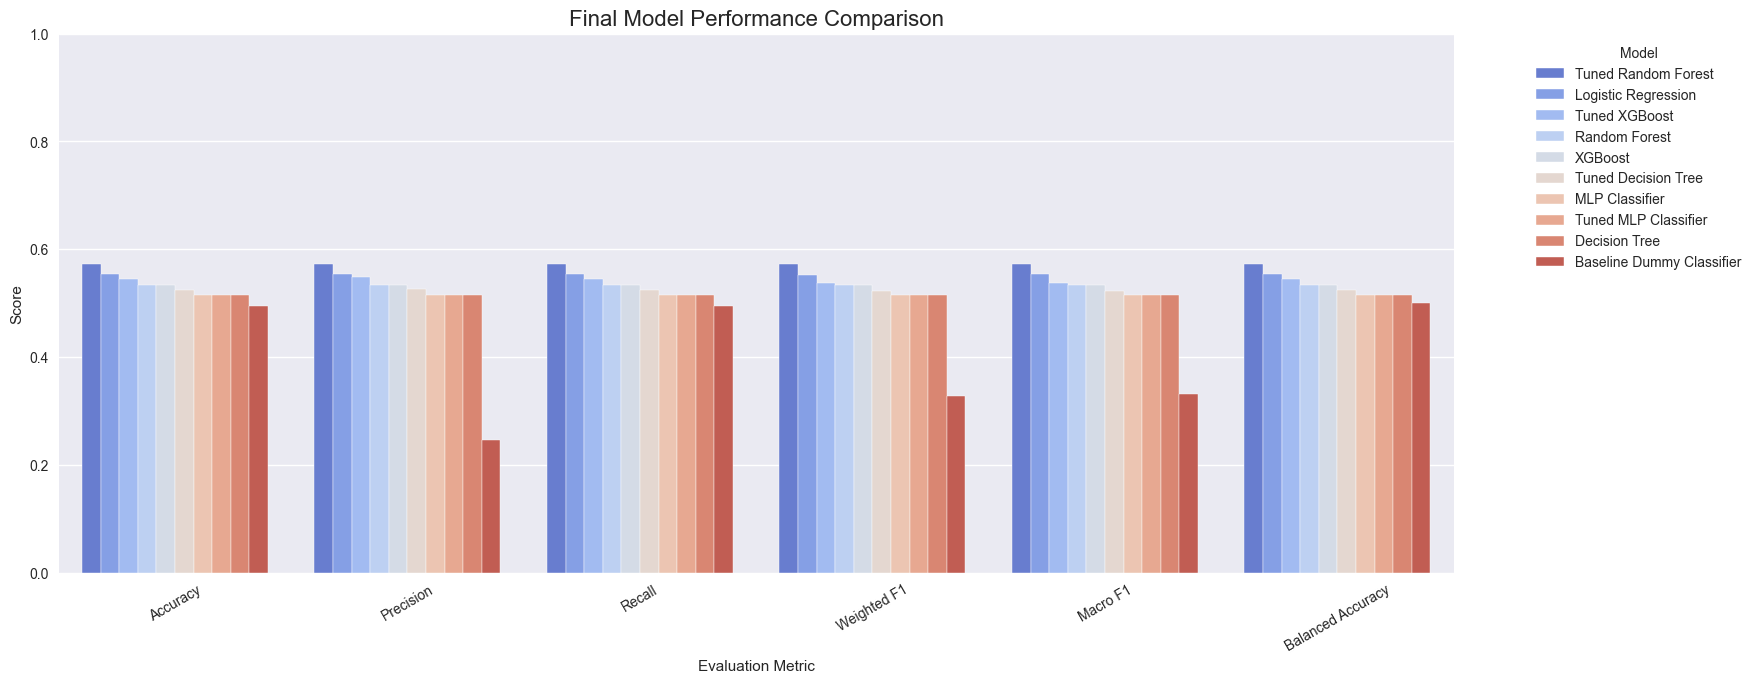

In [127]:
final_model_comparison_melted = final_model_comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(18, 7))

sns.barplot(
    data=final_model_comparison_melted,
    x="Metric",
    y="Score",
    hue="Model",
    palette="coolwarm"
)

plt.ylim(0, 1)

plt.title("Final Model Performance Comparison", fontsize=16)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.xticks(rotation=30)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

<div style="color:#60b9e5;">

## <h4>Final Model Comparison Insights:</h4>

•⁠  ⁠The models were compared using Accuracy, Precision, Recall, Weighted F1, Macro F1, and Balanced Accuracy.

•⁠  ⁠Balanced Accuracy was used as the main selection metric because it measures how well the model performs across both fire severity classes.

•⁠  ⁠Macro F1 was also important because it treats both classes equally, regardless of class size.

•⁠  ⁠The Dummy Classifier provided the minimum benchmark and helped confirm whether the machine learning models learned useful patterns beyond simply predicting the majority class.

•⁠  ⁠Logistic Regression provided a simple linear baseline model and required feature scaling.

•⁠  ⁠Decision Tree, Random Forest, and XGBoost were tested because they can capture non-linear relationships between weather, fire index features, seasonality, and fire severity.

•⁠  ⁠MLP was also tested as a neural-network-based model, but because the dataset is relatively small, it may not necessarily outperform tree-based models.

•⁠  ⁠The final selected model is the one with the strongest Balanced Accuracy, followed by Macro F1 and Weighted F1.

</div>